# CRISP - DM
<h4>Métrica desarrollada con Machine Learning</h4>

<br>

## Importar Librerías

In [ ]:
# StandardScaler -> Estandariza variables (media=0, desviación=1)
from sklearn.preprocessing import StandardScaler

# PCA -> Reducción de dimensionalidad (visualización 2D/3D)
from sklearn.decomposition import PCA

# pandas -> Manipulación y análisis de datos en DataFrames
import pandas as pd

# numpy -> Operaciones numéricas y arrays
import numpy as np

# matplotlib -> Gráficos base
import matplotlib.pyplot as plt

# seaborn -> Visualizaciones estadísticas avanzadas
import seaborn as sns

# inspect -> Inspección de funciones/objetos en runtime
import inspect

# display -> Mostrar DataFrames/objetos enriquecidos
from IPython.display import display

# sys -> Manipulación de rutas y entorno de ejecución
import sys

# sqlite3 -> Interacción con bases de datos SQLite
import sqlite3

# inspect -> Inspección de funciones/objetos en runtime
import inspect

<br>

## Comprensión del Negocio

<h3 style="margin-top:25px;">Objetivo del proyecto:</h3>

El objetivo del proyecto es desarrollar un sistema de **evaluación cuantitativa de jugadores** que permita asignar una **puntuación global (scoring)** a cada futbolista a partir de sus estadísticas de rendimiento.

Para ello, se aplica una técnica de **reducción de dimensionalidad mediante PCA (Principal Component Analysis)**, con el fin de sintetizar múltiples variables en un número reducido de componentes, utilizando el principal de ellos como base para construir un **índice de rendimiento**.

Este enfoque no corresponde a un problema de clasificación ni de regresión, sino a un caso de **aprendizaje no supervisado**, orientado a transformar un conjunto amplio de métricas en una representación más compacta, interpretable y útil para el análisis.

La finalidad es **reducir la complejidad y la redundancia de los datos**, generando una métrica sintética que facilite la comparación entre jugadores y apoye la identificación de perfiles con buen encaje potencial en un equipo.

<h3 style="margin-top:45px;">Contexto deportivo:</h3>

En el fútbol profesional moderno, la toma de decisiones en áreas como el scouting, la dirección deportiva y el análisis de rendimiento se apoya cada vez más en el uso de datos.

Plataformas especializadas como Fbref ofrecen una gran cantidad de métricas avanzadas sobre el rendimiento de los jugadores, lo que genera un entorno muy rico en información, pero también más complejo de interpretar.

En este contexto, analistas y cuerpos técnicos necesitan herramientas capaces de **transformar grandes volúmenes de datos en información clara, sintética y accionable**, facilitando tareas como la identificación de talento, la comparación entre jugadores y la planificación deportiva.

El uso de técnicas de machine learning no supervisado, como la **reducción de dimensionalidad**, permite abordar este problema resumiendo la información estadística en componentes más manejables y representativos.

<h3 style="margin-top:45px;">Descripción del problema:</h3>

Se trata de un problema de **aprendizaje no supervisado**, ya que no se dispone de una variable objetivo que defina explícitamente el rendimiento o la calidad de los jugadores.

El desafío consiste en transformar un conjunto amplio y multidimensional de variables estadísticas en una representación más simple y significativa, minimizando la pérdida de información relevante.

Para ello, se aplica una técnica de **reducción de dimensionalidad (PCA)** que permite:

- Identificar combinaciones lineales de variables que concentran la mayor parte de la varianza del conjunto de datos
- Reducir la redundancia existente entre métricas altamente correlacionadas
- Obtener una base cuantitativa para construir un sistema de puntuación

A partir del componente principal seleccionado, se construye un **índice de scoring**, que permite ordenar y comparar jugadores según su perfil de rendimiento estadístico en función de las variables consideradas en el análisis.

<h3 style="margin-top:45px;">Criterios de éxito:</h3>

El modelo se considerará exitoso si cumple los siguientes criterios:

- **Interpretabilidad**: La puntuación generada debe ser comprensible y tener sentido desde el punto de vista futbolístico, apoyándose en la interpretación de las variables con mayor peso en el componente principal.

- **Coherencia deportiva**: Los jugadores mejor posicionados en el ranking deben corresponderse, de forma razonable, con perfiles de alto rendimiento según el conocimiento experto y el contexto competitivo analizado.

- **Capacidad de síntesis**: El modelo debe ser capaz de resumir múltiples variables en una única métrica o en un conjunto muy reducido de componentes, conservando una parte significativa de la información original.

- **Aplicabilidad práctica**: La métrica obtenida debe integrarse correctamente en la aplicación desarrollada en Streamlit y resultar útil en procesos reales de scouting y análisis de jugadores.

<h3 style="margin-top:45px;">Recursos disponibles:</h3>

- **Dataset de estadísticas de jugadores scrapeado de Fbref** correspondiente a la temporada 2024-2025.

- **Entorno de desarrollo en Python**, utilizando Jupyter Notebook y Visual Studio Code para el análisis, modelado y desarrollo de la aplicación.

- **Librerías de análisis de datos y machine learning** como pandas, numpy, scikit-learn, matplotlib y seaborn para el procesamiento, modelado y visualización de los datos.

- **Conocimiento experto en fútbol y análisis táctico**, fundamental para interpretar los resultados del modelo y validar su coherencia desde una perspectiva deportiva.

<br>

## Comprensión de los Datos

En esta fase del proceso CRISP-DM se aborda el análisis y comprensión del conjunto de datos que será utilizado en el desarrollo del modelo de machine learning.

El dataset utilizado está compuesto por **estadísticas de jugadores pertenecientes a diferentes ligas europeas durante la temporada 2024-2025**, tal y como se detalla en el proceso de extracción descrito en el documento anexo *"TFM_other_documents.ipynb"*. En dicho anexo se llevó a cabo el scraping de información desde Fbref mediante la librería LanusStats, así como su posterior tratamiento, limpieza y depuración.

Es importante destacar que las etapas de **extracción, limpieza y preprocesamiento inicial de los datos** ya han sido realizadas previamente en dicho documento, garantizando que el dataset se encuentra estructurado y listo para su análisis.

Por tanto, en este notebook el enfoque se centra exclusivamente en la **comprensión exploratoria y preparación analítica de los datos**, partiendo de una base ya limpia y consistente, con el objetivo de identificar su estructura, calidad y relaciones entre variables antes de la aplicación de técnicas de reducción de dimensionalidad.

### Carga de Datos

In [5]:
# Agregar una ruta específica a sys.path para que Python pueda encontrar módulos en esa carpeta
sys.path.append(r"../notebooks/Read_file.py")

# Importar el módulo propio donde están definidas funciones personalizadas
import Read_file

# Crear una lista filtrando solo los nombres de las funciones definidas dentro del módulo 'functions_blaya_fbref'
funciones = [f for f, obj in inspect.getmembers(Read_file, inspect.isfunction)]

# Mostrar la lista de nombres de las funciones detectadas en el módulo
print(funciones)

['cargar_archivo', 'display', 'file_inspector', 'flatten_nested_structures', 'folder_inspector', 'json_normalize', 'xml_instance_to_df']


In [6]:
# Importar la función que permite cargar un archivo
from Read_file import cargar_archivo

In [7]:
# Cargar DataFrame
fbref_dataset = cargar_archivo(
    path = "../data/dataset_stats_players_fbref_update.csv",
    type = "CSV",
    see_sample = True,
    see_resum = True
)

Archivo cargado correctamente.
El DataFrame tiene 5607 filas y 191 columnas.


,Id_player,Player,stats_Nation,stats_Pos,stats_Squad,stats_Comp,league,stats_Age,stats_Born,stats_MP,...,misc_Crs,misc_Int,misc_TklW,misc_PKwon,misc_PKcon,misc_OG,misc_Recov,misc_Won,misc_Lost,misc_Won%
0,1,Joshua Acheampong,ENG,DF,Chelsea,Premier League,PL,18,2006,4.0,...,0.0,1.0,1.0,0.0,0.0,0.0,7.0,1.0,6.0,14.3
1,2,Tyler Adams,USA,MF,Bournemouth,Premier League,PL,25,1999,28.0,...,3.0,32.0,50.0,0.0,1.0,0.0,114.0,31.0,18.0,63.3
2,3,Tosin Adarabioyo,ENG,DF,Chelsea,Premier League,PL,26,1997,22.0,...,0.0,11.0,13.0,0.0,0.0,0.0,41.0,42.0,28.0,60.0
3,4,Simon Adingra,CIV,FW,Brighton,Premier League,PL,22,2002,29.0,...,41.0,8.0,14.0,0.0,0.0,0.0,47.0,7.0,4.0,63.6
4,5,Asher Agbinone,ENG,MF,Crystal Palace,Premier League,PL,18,2005,2.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Análisis Exploratorio

In [3]:
# Función para realizar análisis exploratorio básico
def analisis_exploratorio(df = None):

    # Validar que se haya proporcionado un DataFrame
    if df is None:
        raise ValueError("Debes proporcionar un DataFrame")
    
    # Información básica
    print("Información del Dataset:")
    print(df.info())
    
    print("\nDimensiones:")
    print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
    
    print("\nTipos de datos:")
    print(df.dtypes.value_counts())
    
    # Estadísticas descriptivas
    print("\nEstadísticas Descriptivas:")
    print(df.describe(include="all").T)
    
    # Valores faltantes
    print("\nValores faltantes:")
    missing = df.isnull().sum()
    print(missing[missing > 0].sort_values(ascending=False))
    
    # Duplicados exactos
    print("\nDuplicados exactos:")
    print(df.duplicated().sum())
    
    return None

In [8]:
# Realizar análisis exploratorio para el DataFrame cargado 
print(f"\n📊 Análisis exploratorio")
analisis_exploratorio(fbref_dataset)


📊 Análisis exploratorio
Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5607 entries, 0 to 5606
Columns: 191 entries, Id_player to misc_Won%
dtypes: float64(182), int64(3), object(6)
memory usage: 8.2+ MB
None

Dimensiones:
Filas: 5607, Columnas: 191

Tipos de datos:
float64    182
object       6
int64        3
Name: count, dtype: int64

Estadísticas Descriptivas:
               count unique            top  freq       mean          std  min  \
Id_player     5607.0    NaN            NaN   NaN     2804.0  1618.745811  1.0   
Player          5607   5583  Mohamed Bamba     3        NaN          NaN  NaN   
stats_Nation    5607    132            ESP   883        NaN          NaN  NaN   
stats_Pos       5607      4             DF  1962        NaN          NaN  NaN   
stats_Squad     5607    553     Portsmouth    35        NaN          NaN  NaN   
...              ...    ...            ...   ...        ...          ...  ...   
misc_OG       5607.0    NaN           

<h4> Comentario del Análisis Exploratorio: </h4>

El **análisis exploratorio** se realiza sobre un **dataset previamente extraído, tratado y depurado**, lo que permite centrar esta fase en la **comprensión de la estructura de los datos** y en la **identificación de patrones relevantes** para el **modelado posterior**.

El conjunto de datos está formado por **5.607 registros** y **191 variables**, lo que refleja una base **amplia** y con un **alto nivel de detalle estadístico**. La mayor parte de las columnas son **numéricas**, lo que facilita su uso en **técnicas estadísticas** y **métodos de reducción de dimensionalidad como PCA**.

Desde el punto de vista de la **calidad del dato**, el dataset presenta un **nivel muy bajo de valores faltantes**, lo que indica un **buen resultado del proceso previo de limpieza**. Esta consistencia favorece la aplicación de **análisis posteriores sin necesidad de un tratamiento adicional intensivo**.

A nivel descriptivo, se observan varios **patrones relevantes**. En primer lugar, la **distribución de la edad** se sitúa en torno a los **valores esperables en el fútbol profesional**. Además, variables relacionadas con la **participación**, como **minutos disputados**, **partidos jugados** o **titularidades**, muestran una **elevada dispersión**, lo que evidencia una muestra **heterogénea** en términos de **protagonismo competitivo**.

Por otro lado, métricas **ofensivas** como **goles** o **asistencias** presentan **distribuciones asimétricas**, con una **concentración de valores bajos** y una **minoría de jugadores** que acumulan una **producción muy superior al resto**. Este comportamiento es **coherente con la naturaleza del rendimiento futbolístico**, donde determinadas acciones tienden a concentrarse en **perfiles concretos**.

En conjunto, el dataset presenta una **estructura rica, consistente y adecuada para análisis avanzados**. No obstante, la **alta dimensionalidad** y la **posible redundancia entre métricas** hacen necesario un **estudio más profundo de las relaciones entre variables** antes de aplicar **técnicas de reducción de dimensionalidad**.

### Visualizaciones Iniciales

In [11]:
# Función para realizar visualizaciones iniciales
def visualizaciones_iniciales(df = None, top_n_std = 10, top_n_corr = 15):

    # Validar que se haya proporcionado un DataFrame
    if df is None:
        raise ValueError("Debes proporcionar un DataFrame")
    
    # Configuración de estilo
    sns.set_style("whitegrid")

    # ----- IDENTIFICACIÓN DE VARIABLES -----
    
    # Separar variables numéricas y categóricas
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(include=["object", "category"]).columns

    # Información general del dataset
    print(f"📊 Dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
    print(f"Variables numéricas: {len(num_cols)}")
    print(f"Variables categóricas: {len(cat_cols)}")

    # ----- DISTRIBUCIÓN DE LOS VALORES NÚMERICOS -----
    
    # Distribución global de todos los valores numéricos
    plt.figure(figsize=(8, 4))
    sns.histplot(df[num_cols].values.flatten(), bins=50, color='skyblue')
    plt.title("Distribución global de valores numéricos")
    plt.show()

    # ----- ANÁLISIS DE VALORES NULOS -----

    # Conteo y porcentaje de valores nulos
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100

    # Resumen estructurado de valores nulos
    missing_summary = pd.DataFrame({
        "missing_count": missing,
        "missing_pct": missing_pct
    }).sort_values("missing_pct", ascending=False)
    
    # Visualización de variables con missing values
    if (missing > 0).any():
        plt.figure(figsize=(10, 4))
        missing[missing > 0].sort_values(ascending=False).plot(kind="bar")
        plt.title("Valores faltantes por variable")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # ----- VARIABLES CATEGÓRICAS -----

    # Resumen de cardinalidad en variables categóricas
    cat_summary = pd.DataFrame({
        "column": cat_cols,
        "n_unique": [df[col].nunique(dropna=True) for col in cat_cols]
    }).sort_values("n_unique", ascending=False)

    print("\n📌 Resumen de variables categóricas:")
    print(cat_summary)
    
    # ----- VARIABLES CON MAYOR DISPERSIÓN -----

    # Variables más dispersas
    if len(num_cols) > 0:
        top_std = df[num_cols].std().sort_values(ascending=False).head(top_n_std)

        plt.figure(figsize=(12, 5))
        sns.boxplot(data=df[top_std.index])
        plt.xticks(rotation=45, ha="right")
        plt.title("Variables numéricas con mayor dispersión")
        plt.tight_layout()
        plt.show()

    # ----- MATRIZ DE CORRELACIÓN -----

    corr_matrix = None
    top_corr_pairs = None

    if len(num_cols) > 1:

        # Cálculo de matriz de correlación entre variables numéricas
        corr_matrix = df[num_cols].corr()

        # Convertir matriz en pares de variables
        corr_pairs = (
            corr_matrix.abs()
            .unstack()
            .reset_index()
        )
        corr_pairs.columns = ["var1", "var2", "corr"]

        # Eliminar autocorrelaciones (variable consigo misma)
        corr_pairs = corr_pairs[corr_pairs["var1"] != corr_pairs["var2"]]

        # Seleccionar correlaciones más fuertes
        top_corr_pairs = corr_pairs.sort_values("corr", ascending=False).head(15)

        # Heatmap solo si hay suficientes variables
        if len(num_cols) > 10:
            plt.figure(figsize=(8, 6))
            sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.5)
            plt.title("Correlation Matrix")
            plt.show()

    # Devolver resumen completo del análisis exploratorio
    return {
        "num_cols": list(num_cols),
        "cat_cols": list(cat_cols),
        "missing_summary": missing_summary,
        "cat_summary": cat_summary,
        "correlation_matrix": corr_matrix,
        "top_correlations": top_corr_pairs
    }


===== Visualizaciones iniciales =====
📊 Dataset: 5607 filas x 191 columnas
Variables numéricas: 185
Variables categóricas: 6


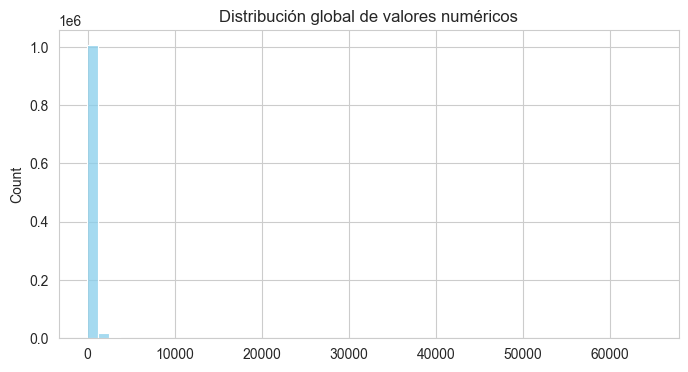

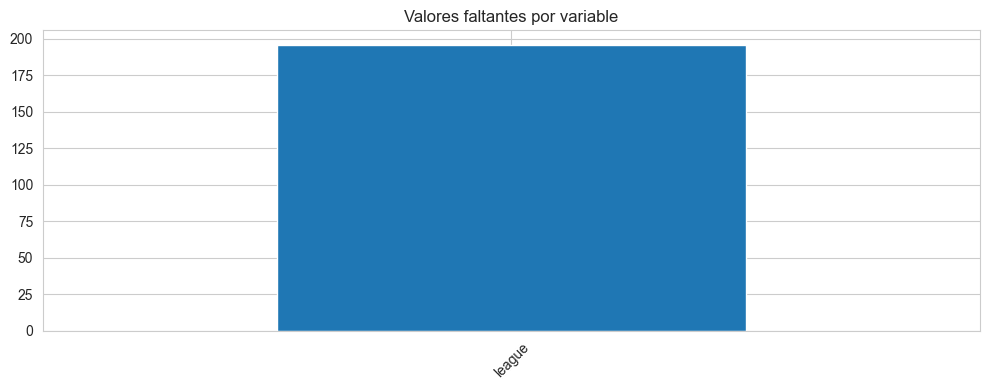


📌 Resumen de variables categóricas:
         column  n_unique
0        Player      5583
3   stats_Squad       553
1  stats_Nation       132
4    stats_Comp        42
5        league        10
2     stats_Pos         4


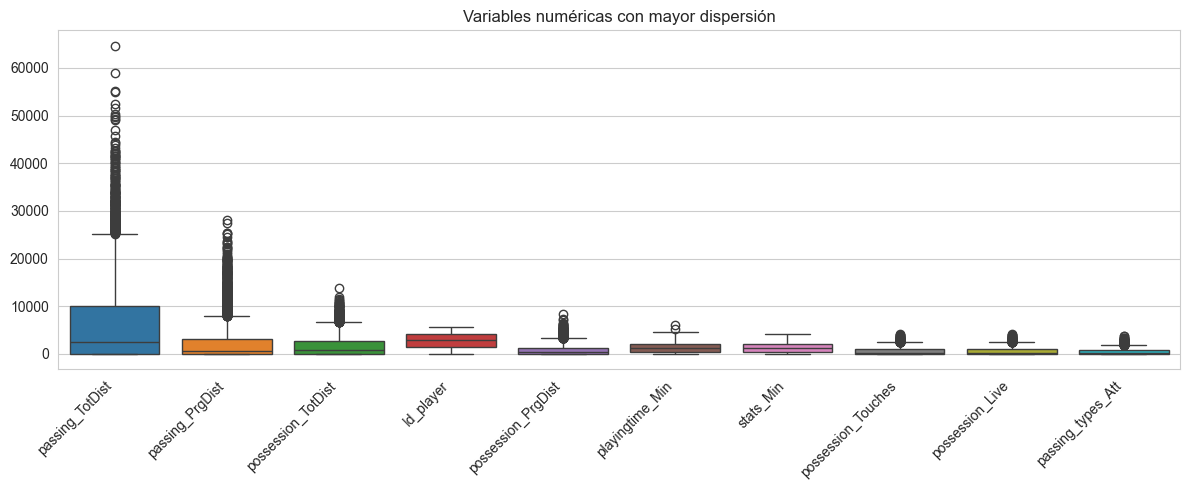

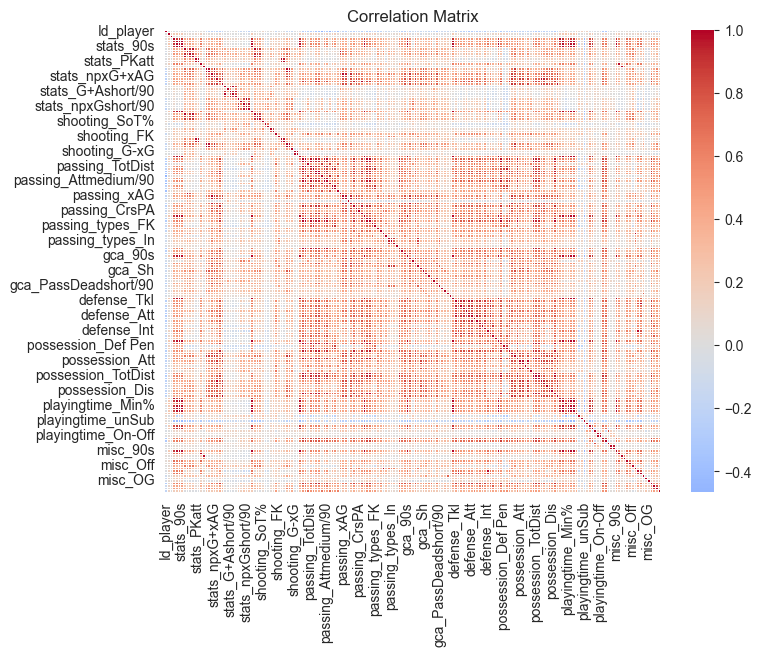

In [12]:
# Realizar visualizaciones iniciales para el DataFrame cargado
print(f"\n===== Visualizaciones iniciales =====")
resultados = visualizaciones_iniciales(fbref_dataset)

<h4> Comentario del Análisis de Visualizaciones: </h4>

Las **visualizaciones iniciales** permiten **complementar el análisis exploratorio** al ofrecer una visión más clara de la **distribución de las variables**, la **presencia de posibles valores extremos** y el **grado de relación entre distintas métricas** del dataset.

El conjunto de datos combina un **gran número de variables numéricas** que recogen distintas dimensiones del **rendimiento futbolístico**, como **participación**, **producción ofensiva**, **contribución defensiva**, **posesión** y **creación de juego**. Esta **riqueza descriptiva** aporta **valor analítico**, aunque también incrementa la **probabilidad de redundancia** entre variables **estrechamente relacionadas**.

En cuanto a las **variables categóricas**, se observa una **alta diversidad** de **jugadores**, **nacionalidades**, **competiciones** y **equipos**. Esta variedad confirma que se trata de un dataset **multicompetición** y con **elevado contexto heterogéneo**. En algunos casos, la **cardinalidad de la variable de equipo** puede verse afectada por jugadores que han pertenecido a **más de un club** durante el periodo analizado, lo que debe tenerse en cuenta en la **interpretación de los resultados**.

Uno de los **hallazgos más relevantes** proviene del **análisis de correlaciones**. Se detectan **relaciones muy elevadas** entre variables de **volumen de juego**, como **minutos**, **partidos** o **titularidades**, así como entre métricas pertenecientes a un **mismo bloque funcional**. Este patrón sugiere la existencia de **información redundante** y confirma que muchas variables **capturan dimensiones similares del rendimiento**.

Además, la presencia de **correlaciones muy altas** entre determinadas métricas puede deberse a **variables derivadas entre sí**, **versiones normalizadas por 90 minutos** o **indicadores construidos a partir de una misma base estadística**. Esta **estructura interdependiente** refuerza la **conveniencia de aplicar técnicas de reducción de dimensionalidad**.

En conjunto, las visualizaciones muestran que el dataset es **rico en información**, pero también **altamente correlacionado**. Por ello, resulta especialmente adecuado para una fase posterior de **selección o síntesis de variables**, orientada a construir una representación **más compacta e interpretable** del rendimiento de los jugadores.

<br>

## Preparación de Datos

### Analizar las correlaciones

In [13]:
# Función para analizar inteligentemente la matriz de correlación
def correlation_intelligence(corr_matrix = None, threshold = 0.7, top_n = 20):

    # Validar que la matriz existe
    if corr_matrix is None:
        raise ValueError("corr_matrix no puede ser None")

    # Validar tipo de dato
    if not isinstance(corr_matrix, pd.DataFrame):
        raise TypeError(f"corr_matrix debe ser DataFrame, no {type(corr_matrix)}")

    # Validar que no esté vacía
    if corr_matrix.empty:
        raise ValueError("corr_matrix está vacía")

    # Validar que sea cuadrada
    if corr_matrix.shape[0] != corr_matrix.shape[1]:
        raise ValueError("corr_matrix debe ser cuadrada")

    # Validar rango del threshold
    if not (0 <= threshold <= 1):
        raise ValueError("threshold debe estar entre 0 y 1")

    # Validar top_n
    if top_n <= 0:
        raise ValueError("top_n debe ser mayor que 0")
    
    # Triángulo superior para evitar duplicados simétricos
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

    corr_pairs = (
        corr_matrix.where(mask)
        .stack()
        .reset_index()
    )
    corr_pairs.columns = ["var1", "var2", "corr"]

    if corr_pairs.empty:
        raise ValueError("No hay pares de correlación válidos tras limpieza")

    # Top correlaciones positivas
    top_positive = (
        corr_pairs
        .sort_values("corr", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    # Top correlaciones negativas
    top_negative = (
        corr_pairs
        .sort_values("corr", ascending=True)
        .head(top_n)
        .reset_index(drop=True)
    )

    # Variables redundantes según umbral
    redundant = (
        corr_pairs[abs(corr_pairs["corr"]) >= threshold]
        .assign(abs_corr=lambda x: x["corr"].abs())
        .sort_values("abs_corr", ascending=False)
        .reset_index(drop=True)
    )

    if redundant.empty:
        print("⚠️ No se encontraron features redundantes con el threshold dado")

    # Fuerza media de cada variable: media de correlación absoluta excluyendo diagonal
    abs_corr = corr_matrix.abs().copy()
    np.fill_diagonal(abs_corr.values, np.nan)

    # Cálculo de fuerza media de cada variable
    strength = (
        abs_corr.mean(axis=1, skipna=True)
        .sort_values(ascending=False)
        .reset_index()
    )
    strength.columns = ["variable", "avg_abs_correlation"]

    if strength["avg_abs_correlation"].isnull().any():
        raise ValueError("Hay valores nulos en feature_strength")

    results = {
        "top_positive_correlations": top_positive,
        "top_negative_correlations": top_negative,
        "redundant_features": redundant,
        "feature_strength": strength
    }

    print("✅ correlation_intelligence OK")
    print(f"Variables: {corr_matrix.shape[0]}")
    print(f"Pares evaluados: {len(corr_pairs)}")
    print(f"Redundancias detectadas: {len(redundant)}")

    return results

In [14]:
# Llamar a la función para analizar de forma inteligente la matriz de correlación
correlation_results = correlation_intelligence(
    corr_matrix = resultados["correlation_matrix"]
)   

✅ correlation_intelligence OK
Variables: 185
Pares evaluados: 17020
Redundancias detectadas: 1303


<h4> Comentario del Análisis de Correlaciones: </h4>

El **análisis de correlaciones** ha permitido identificar la **estructura relacional del dataset** y evaluar el **grado de dependencia** existente entre las distintas variables estadísticas.

En primer lugar, se observan **correlaciones muy elevadas**, en algunos casos incluso **próximas a 1**, entre variables pertenecientes a un **mismo bloque funcional del juego**, como **shooting**, **passing**, **defense** o **possession**. Este comportamiento indica que muchas métricas están **estrechamente relacionadas entre sí** y que, en algunos casos, pueden **derivar de una misma fuente estadística** o representar **versiones normalizadas de una misma información**.

También se detectan **relaciones muy fuertes** entre variables de **volumen de participación**, como los **minutos disputados**, los **partidos jugados** o las **titularidades**. Esto confirma que existe una **dimensión estructural asociada a la presencia competitiva del jugador** que atraviesa buena parte del dataset.

Por otro lado, algunas **correlaciones negativas** reflejan **relaciones inversas esperables** entre variables de **participación alta y baja**, o entre métricas que describen **comportamientos opuestos dentro del juego**. En este sentido, la **matriz de correlación** no solo muestra **redundancia**, sino también cierta **coherencia interna** en la forma en que las variables representan **distintos perfiles de rendimiento**.

En conjunto, el análisis evidencia que el dataset es **rico en información**, pero también **altamente interdependiente**, con múltiples variables que describen **fenómenos similares desde perspectivas distintas**. Este hallazgo **no supone una limitación** para el proyecto; al contrario, refuerza la **idoneidad de aplicar PCA**, ya que esta técnica permite **sintetizar esa redundancia** en un número reducido de **componentes más manejables e interpretables**.

Además, la presencia de **correlaciones extremadamente altas** sugiere **revisar cuidadosamente** la inclusión de variables **prácticamente duplicadas o derivadas**, con el fin de evitar una **sobre-representación de determinadas dimensiones del rendimiento** en la construcción del **scoring final**.

### Feature Engineering

En esta fase se procede a la **generación de nuevas variables derivadas** orientadas a **mejorar la comparabilidad** y la **capacidad descriptiva del dataset** de cara al **análisis posterior**.

En primer lugar, se construyen **métricas expresadas por 90 minutos**, con el objetivo de **ajustar el rendimiento al tiempo de juego** y permitir **comparaciones más homogéneas** entre jugadores con **distinta participación competitiva**.

Además, se generan **variables adicionales de eficiencia y rendimiento relativo**, como la **relación entre goles y xG** o la **proporción de conducciones progresivas respecto al total de conducciones**, con el fin de capturar no solo el **volumen de acciones**, sino también ciertos **matices de su productividad estadística**.

Por último, el proceso incorpora un **tratamiento robusto de la base temporal utilizada para el cálculo**, contemplando **distintas fuentes de minutos disponibles** y controlando situaciones de **denominadores nulos**, con el objetivo de mantener la **consistencia de las nuevas variables generadas**.

In [15]:
# Función para realizar ingeniería de características específicas para datos de fútbol
def feature_engineering(df = None, min_minutes_threshold = None):

    # Validar que se haya proporcionado un DataFrame
    if df is None:
        raise ValueError("df no puede ser None")

    # Validar tipo de dato
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"df debe ser DataFrame, no {type(df)}")

    # Crear una copia del DataFrame para evitar modificar el original
    df = df.copy()
    
    # Lista para rastrear las nuevas features creadas
    created_features = []

    # Base temporal para métricas por 90
    if "stats_90s" in df.columns:
        time_base = df["stats_90s"]
    elif "playingtime_Min" in df.columns:
        time_base = df["playingtime_Min"] / 90
    else:
        raise ValueError("No se encuentra una variable válida de minutos")

    # Evitar divisiones por cero marcando como NaN donde la base temporal es 0
    time_base = time_base.replace(0, np.nan)

    # Función auxiliar para calcular métricas por 90 minutos
    def per90(col):
        return np.where(time_base.notna(), df[col] / time_base, np.nan)

    # Crear métricas por 90 minutos para las estadísticas clave
    per90_map = {
        "stats_Gls": "goals_per90",
        "stats_xG": "xg_per90",
        "stats_Ast": "assists_per90",
        "passing_KP": "key_passes_per90",
        "passing_PrgP": "prog_passes_per90",
        "defense_Tkl": "tackles_per90",
        "defense_Int": "interceptions_per90",
        "possession_PrgC": "prog_carries_per90"
    }

    # Iterar sobre el mapa de columnas para crear las métricas por 90 minutos
    for original_col, new_col in per90_map.items():
        if original_col in df.columns:
            df[new_col] = per90(original_col)
            created_features.append(new_col)

    # Eficiencia de finalización
    if {"stats_Gls", "stats_xG"}.issubset(df.columns):
        df["finishing_efficiency"] = np.where(
            df["stats_xG"] > 0,
            df["stats_Gls"] / df["stats_xG"],
            np.nan
        )
        created_features.append("finishing_efficiency")

    # Ratio de progresión con balón
    if {"possession_Carries", "possession_PrgC"}.issubset(df.columns):
        df["progression_ratio"] = np.where(
            df["possession_Carries"] > 0,
            df["possession_PrgC"] / df["possession_Carries"],
            np.nan
        )
        created_features.append("progression_ratio")

    # Umbral opcional de minutos para estabilizar métricas
    if min_minutes_threshold is not None and "playingtime_Min" in df.columns:
        low_minutes_mask = df["playingtime_Min"] < min_minutes_threshold
        per90_cols = [col for col in created_features if col.endswith("_per90")]
        for col in per90_cols + ["finishing_efficiency", "progression_ratio"]:
            if col in df.columns:
                df.loc[low_minutes_mask, col] = np.nan

    print("✅ feature_engineering OK")
    print(f"Features creadas: {created_features}")

    return df

In [16]:
# Llamar a la función para enriqueder el dataset
fbref_enriquecido = feature_engineering(
    df = fbref_dataset
)

✅ feature_engineering OK
Features creadas: ['goals_per90', 'xg_per90', 'assists_per90', 'key_passes_per90', 'prog_passes_per90', 'tackles_per90', 'interceptions_per90', 'prog_carries_per90', 'finishing_efficiency', 'progression_ratio']


### Preparación para Modelado

In [51]:
# Función para preparar datasets de PCA por posición
def prepare_pca_datasets_by_position(df = None, min_minutes = None, corr_threshold = None, missing_feature_threshold = None, scale = True, feature_map = None):
    
    # Función auxiliar para construir un identificador único para cada jugador
    def _build_player_uid(local_df: pd.DataFrame) -> pd.Series:
        
        # Crea un identificador único compuesto para trazabilidad
        required = ["Id_player", "Player", "stats_Nation", "stats_Pos"]

        if all(col in local_df.columns for col in required):
            return (
                local_df["Id_player"].astype(str) + "_"
                + local_df["Player"].astype(str) + "_"
                + local_df["stats_Nation"].astype(str) + "_"
                + local_df["stats_Pos"].astype(str)
            )

        # Si faltan columnas clave, usa el índice
        return local_df.index.astype(str)

    # Función auxiliar para eliminar variables casi duplicadas
    def _drop_near_duplicate_features(local_features_df: pd.DataFrame, local_corr_threshold: float = 0.95):
        
        # Si hay 1 o 0 variables, no hay redundancia posible
        if local_features_df.shape[1] <= 1:
            return local_features_df.copy(), []

        # Matriz de correlación absoluta
        corr_matrix = local_features_df.corr().abs()

        # Triángulo superior para evitar duplicados simétricos
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        # Pares de variables con alta correlación absoluta
        pairs = (
            upper.stack()
            .reset_index()
            .rename(columns={"level_0": "var1", "level_1": "var2", 0: "abs_corr"})
            .sort_values("abs_corr", ascending=False)
        )

        # Filtrar solo pares con correlación por encima del umbral
        high_corr_pairs = pairs[pairs["abs_corr"] >= local_corr_threshold].copy()

        if high_corr_pairs.empty:
            return local_features_df.copy(), []

        # Fuerza media de correlación absoluta para cada variable
        feature_strength = corr_matrix.mean(axis=1)

        to_drop = set()

        # Iterar sobre pares redundantes y eliminar la variable más "débil" según fuerza media
        for _, row in high_corr_pairs.iterrows():
            v1, v2 = row["var1"], row["var2"]

            if v1 in to_drop or v2 in to_drop:
                continue

            s1 = feature_strength[v1]
            s2 = feature_strength[v2]

            if s1 > s2:
                to_drop.add(v1)
            elif s2 > s1:
                to_drop.add(v2)
            else:
                to_drop.add(sorted([v1, v2])[1])

        filtered = local_features_df.drop(columns=list(to_drop), errors="ignore")

        return filtered, sorted(list(to_drop))

    # Validaciones básicas
    if df is None or not isinstance(df, pd.DataFrame):
        raise ValueError("Debes proporcionar un DataFrame válido.")

    # Crear una copia para no modificar el original
    data = df.copy()

    # Validar que las columnas clave para el proceso estén presentes
    required_cols = ["stats_Pos", "playingtime_Min"]

    # Verificar que existan las columnas requeridas para el proceso
    missing_required = [c for c in required_cols if c not in data.columns]

    if missing_required:
        raise ValueError(f"Faltan columnas obligatorias: {missing_required}")

    # Crear identificador único
    data["player_uid"] = _build_player_uid(data)

    # Sustituir infinitos por NaN en columnas numéricas
    num_cols = data.select_dtypes(include=np.number).columns
    data[num_cols] = data[num_cols].replace([np.inf, -np.inf], np.nan)

    # Excluir Porteros
    data = data[data["stats_Pos"].isin(["DF", "MF", "FW"])].copy()

    # Feature map por defecto si no se proporciona uno específico
    default_feature_map = {
        "DF": [
            "tackles_per90",
            "interceptions_per90",
            "prog_passes_per90",
            "prog_carries_per90",
            "key_passes_per90",
            "gca_SCA90",
            "passing_Cmp%",
            "defense_Tkl%",
            "misc_Won%",
        ],
        "MF": [
            "tackles_per90",
            "interceptions_per90",
            "prog_passes_per90",
            "prog_carries_per90",
            "key_passes_per90",
            "assists_per90",
            "xg_per90",
            "gca_SCA90",
            "gca_GCA90",
            "passing_Cmp%",
        ],
        "FW": [
            "goals_per90",
            "xg_per90",
            "assists_per90",
            "key_passes_per90",
            "prog_passes_per90",
            "prog_carries_per90",
            "shooting_Sh/90",
            "shooting_SoT/90",
            "gca_SCA90",
            "gca_GCA90",
        ],
    }

    if feature_map is None:
        feature_map = default_feature_map

    # Metadatos a conservar
    metadata_cols = [
        col for col in [
            "player_uid",
            "Id_player",
            "Player",
            "stats_Nation",
            "stats_Pos",
            "stats_Squad",
            "stats_Comp",
            "league",
            "playingtime_Min"
        ] if col in data.columns
    ]

    # Preparar outputs
    output = {}
    report_rows = []

    # Iterar por posición
    for pos in ["DF", "MF", "FW"]:

        # Dataset bruto de esa posición antes del filtro de minutos
        pos_df_full = data[data["stats_Pos"] == pos].copy()
        players_initial_position = len(pos_df_full)

        # Aplicar filtro de minutos
        pos_df = pos_df_full[pos_df_full["playingtime_Min"] >= min_minutes].copy()
        players_after_minutes_filter = len(pos_df)

        # Calcular jugadores eliminados por filtro de minutos
        players_removed_by_minutes = players_initial_position - players_after_minutes_filter

        if players_initial_position > 0:
            minute_filter_loss_pct = round(players_removed_by_minutes / players_initial_position, 4)
        else:
            minute_filter_loss_pct = 0.0

        # Seleccionar solo las features que existan realmente
        selected_features = [c for c in feature_map.get(pos, []) if c in pos_df.columns]

        # Si no hay features disponibles, devolver error controlado
        if len(selected_features) == 0:
            output[pos] = {
                "error": f"No hay features disponibles para {pos}",
                "raw_df": pos_df,
            }

            report_rows.append({
                "position": pos,
                "players_initial_position": players_initial_position,
                "players_removed_by_minutes": players_removed_by_minutes,
                "minute_filter_loss_pct": minute_filter_loss_pct,
                "players_after_minutes_filter": players_after_minutes_filter,
                "players_final": 0,
                "final_retention_pct": 0.0,
                "final_loss_pct": 1.0 if players_initial_position > 0 else 0.0,
                "features_requested": 0,
                "features_dropped_high_missing": 0,
                "features_dropped_constant": 0,
                "features_dropped_high_corr": 0,
                "features_final": 0,
            })
            continue

        # Dataset de trabajo con metadata + features seleccionadas
        work_df = pos_df[metadata_cols + selected_features].copy()

        # Detectar features con demasiado missing dentro de la posición
        feature_missing = work_df[selected_features].isnull().mean().sort_values(ascending=False)
        dropped_high_missing = feature_missing[feature_missing > missing_feature_threshold].index.tolist()

        # Mantener solo features válidas tras el filtro de missing
        final_features = [c for c in selected_features if c not in dropped_high_missing]

        # Si quedan menos de 2 features, PCA ya no tendría sentido
        if len(final_features) < 2:
            output[pos] = {
                "error": f"Tras filtrar missing quedan menos de 2 features para {pos}",
                "raw_df": work_df,
                "dropped_high_missing": dropped_high_missing,
            }

            players_final = len(work_df)

            # Calcular métricas de retención final aunque no se pueda modelar
            if players_initial_position > 0:
                final_retention_pct = round(players_final / players_initial_position, 4)
                final_loss_pct = round(1 - (players_final / players_initial_position), 4)
            else:
                final_retention_pct = 0.0
                final_loss_pct = 0.0

            # Guardar fila del global_report incluso en caso de error
            report_rows.append({
                "position": pos,
                "players_initial_position": players_initial_position,
                "players_removed_by_minutes": players_removed_by_minutes,
                "minute_filter_loss_pct": minute_filter_loss_pct,
                "players_after_minutes_filter": players_after_minutes_filter,
                "players_final": players_final,
                "final_retention_pct": final_retention_pct,
                "final_loss_pct": final_loss_pct,
                "features_requested": len(selected_features),
                "features_dropped_high_missing": len(dropped_high_missing),
                "features_dropped_constant": 0,
                "features_dropped_high_corr": 0,
                "features_final": len(final_features),
            })
            continue

        # Dataset de modelado
        modeling_df = work_df[final_features].copy()

        # Imputación con mediana dentro de la posición
        medians = modeling_df.median()
        modeling_df = modeling_df.fillna(medians)

        # Eliminar features constantes
        nunique = modeling_df.nunique(dropna=True)
        constant_features = nunique[nunique <= 1].index.tolist()

        if constant_features:
            modeling_df = modeling_df.drop(columns=constant_features, errors="ignore")

        # Eliminar features casi duplicadas por alta correlación
        filtered_df, dropped_high_corr = _drop_near_duplicate_features(
            modeling_df,
            local_corr_threshold=corr_threshold
        )

        # Escalar si se solicita
        if scale:
            scaler = StandardScaler()
            scaled_array = scaler.fit_transform(filtered_df)
            scaled_df = pd.DataFrame(
                scaled_array,
                columns=filtered_df.columns,
                index=filtered_df.index
            )
        else:
            scaler = None
            scaled_df = filtered_df.copy()

        # Mantener metadatos alineados
        players_info = work_df.loc[filtered_df.index, metadata_cols].copy()

        # Calcular métricas de retención final
        players_final = len(filtered_df)

        if players_initial_position > 0:
            final_retention_pct = round(players_final / players_initial_position, 4)
            final_loss_pct = round(1 - (players_final / players_initial_position), 4)
        else:
            final_retention_pct = 0.0
            final_loss_pct = 0.0

        # Guardar salida por posición
        output[pos] = {
            "players_info": players_info,
            "raw_features_df": modeling_df,
            "filtered_df": filtered_df,
            "scaled_df": scaled_df,
            "features_used": list(filtered_df.columns),
            "features_requested": selected_features,
            "dropped_high_missing": dropped_high_missing,
            "dropped_constant": constant_features,
            "dropped_high_corr": dropped_high_corr,
            "imputation_medians": medians.to_dict(),
            "scaler": scaler,
            "n_players": players_final,
        }

        # Guardar fila del global_report
        report_rows.append({
            "position": pos,
            "players_initial_position": players_initial_position,
            "players_removed_by_minutes": players_removed_by_minutes,
            "minute_filter_loss_pct": minute_filter_loss_pct,
            "players_after_minutes_filter": players_after_minutes_filter,
            "players_final": players_final,
            "final_retention_pct": final_retention_pct,
            "final_loss_pct": final_loss_pct,
            "features_requested": len(selected_features),
            "features_dropped_high_missing": len(dropped_high_missing),
            "features_dropped_constant": len(constant_features),
            "features_dropped_high_corr": len(dropped_high_corr),
            "features_final": filtered_df.shape[1],
        })

    # Global report
    output["global_report"] = pd.DataFrame(report_rows)
    display(output["global_report"])

    return output

In [82]:
# Llamar a la función para preparar datasets de PCA por posición
datasets_pca = prepare_pca_datasets_by_position(
    df = fbref_enriquecido,
    min_minutes = 1500,
    corr_threshold = 0.95,
    missing_feature_threshold = 0.35,
    scale = True
)

,position,players_initial_position,players_removed_by_minutes,minute_filter_loss_pct,players_after_minutes_filter,players_final,final_retention_pct,final_loss_pct,features_requested,features_dropped_high_missing,features_dropped_constant,features_dropped_high_corr,features_final
0,DF,1962,1012,0.5158,950,950,0.4842,0.5158,9,0,0,0,9
1,MF,1891,1134,0.5997,757,757,0.4003,0.5997,10,0,0,0,10
2,FW,1327,899,0.6775,428,428,0.3225,0.6775,10,0,0,0,10


El proceso de **preparación del dataset para el modelado** se ha llevado a cabo mediante una combinación de **filtrado, selección de variables, imputación y estandarización**, con el objetivo de obtener una base numérica consistente y adecuada para la aplicación de técnicas de **reducción de dimensionalidad**.

En primer lugar, se ha optado por realizar la preparación **de forma diferenciada según la posición del jugador**, generando conjuntos de datos específicos para **defensas (DF), centrocampistas (MF) y delanteros (FW)**. Esta decisión responde a la necesidad de comparar perfiles futbolísticos homogéneos entre sí, evitando que un único espacio analítico mezcle roles con exigencias y patrones estadísticos muy distintos. Por su parte, los **porteros (GK)** han sido excluidos del análisis, ya que el dataset disponible no incorpora métricas específicas de portería que permitan evaluarlos de forma rigurosa dentro de su propio contexto competitivo.

A continuación, se aplica un **filtro mínimo de 1500 minutos jugados**, con el fin de excluir jugadores cuya muestra de participación sea demasiado reducida y pueda distorsionar la interpretación de métricas relativas, especialmente aquellas expresadas por 90 minutos. Esta decisión no se adoptó de forma arbitraria, sino tras realizar pruebas con distintos umbrales de minutos y comparar su impacto sobre la estabilidad del pipeline y la coherencia de los rankings obtenidos. Aunque filtros menos restrictivos permitían conservar una muestra más amplia, también incrementaban la presencia de ruido estadístico asociado a jugadores con participación reducida. En cambio, el umbral de 1500 minutos proporcionó una estructura más estable, favoreció una representación más compacta en el PCA y dio lugar a resultados más consistentes desde el punto de vista futbolístico, especialmente en el caso de centrocampistas y delanteros. Por ello, se consideró el criterio más adecuado para el modelado final.

Posteriormente, para cada grupo posicional se selecciona un conjunto de variables orientadas al **rendimiento futbolístico**, priorizando métricas **por 90 minutos, porcentajes e indicadores de producción**, y excluyendo deliberadamente variables de **volumen de juego** como minutos, partidos o titularidades. De este modo, se busca que el análisis posterior se centre en la calidad y el perfil estadístico del rendimiento, y no en la simple acumulación de participación.

En relación con la calidad del dato, los valores inválidos se transforman adecuadamente y los valores ausentes se tratan mediante **imputación por la mediana dentro de cada posición**, lo que permite preservar la muestra útil sin introducir una pérdida innecesaria de jugadores. Además, se eliminan las variables constantes y se realiza un filtrado conservador de variables **altamente redundantes**, suprimiendo únicamente aquellas características casi duplicadas desde el punto de vista correlacional. Este paso no pretende eliminar la correlación del dataset, ya que esta resulta útil en PCA, sino evitar una sobre-representación artificial de determinadas dimensiones del rendimiento.

Finalmente, se aplica un proceso de **estandarización**, imprescindible en técnicas sensibles a la escala como PCA, para asegurar que todas las variables contribuyan de forma equilibrada al cálculo de los componentes principales.

Como resultado, se obtiene un pipeline de preparación **estable y coherente**, en el que la pérdida de observaciones queda asociada fundamentalmente al filtro mínimo de minutos, sin reducciones adicionales relevantes en las fases posteriores de imputación, selección de variables y escalado. Esto permite disponer de tres conjuntos de datos sólidos y comparables, listos para abordar el modelado mediante PCA y la construcción de un **scoring específico por posición**.

<br>

## Modelado

### Reducción de dimensionalidad mediante PCA

In [83]:
# Función para ajustar PCA por posición
def fit_pca_by_position(datasets_pca = None, variance_threshold = 0.80, fixed_n_components = None, positions = None):
    
    # Función auxiliar para validar input
    def _validate_inputs():
        
        # Validar que se haya proporcionado un diccionario de datasets
        if not isinstance(datasets_pca, dict):
            raise ValueError("datasets_pca debe ser un diccionario.")

        # Validar que el diccionario no esté vacío
        if fixed_n_components is not None:
            if not isinstance(fixed_n_components, int) or fixed_n_components < 1:
                raise ValueError("fixed_n_components debe ser un entero mayor que 0.")

        # Si no se fija un número de componentes, validar el umbral de varianza
        if fixed_n_components is None:
            if not (0 < variance_threshold <= 1):
                raise ValueError("variance_threshold debe estar entre 0 y 1.")

    # Función auxiliar para obtener posiciones válidas
    def _get_valid_positions():
        
        # Si no se especifican posiciones, se asume que se quieren procesar todas las posiciones disponibles
        default_positions = ["DF", "MF", "FW"]

        # Si se proporcionan posiciones, se validan contra el diccionario de datasets
        if positions is None:
            pos_list = default_positions
        else:
            pos_list = positions

        # Validar que las posiciones solicitadas existan en el diccionario de datasets
        valid_positions = []
        
        # Iterar sobre las posiciones solicitadas y verificar que existan en datasets_pca y que tengan un 'scaled_df' válido
        for pos in pos_list:
            if pos in datasets_pca and isinstance(datasets_pca[pos], dict):
                if "scaled_df" in datasets_pca[pos]:
                    valid_positions.append(pos)

        if len(valid_positions) == 0:
            raise ValueError("No se han encontrado posiciones válidas con 'scaled_df' en datasets_pca.")

        return valid_positions

    # Función auxiliar para construir tabla de varianza explicada
    def _build_explained_variance_table(pca_model):
        
        # Construir un DataFrame con la varianza explicada por cada componente, la varianza acumulada y los eigenvalues
        explained_df = pd.DataFrame({
            "component": [f"PC{i+1}" for i in range(len(pca_model.explained_variance_ratio_))],
            "explained_variance_ratio": pca_model.explained_variance_ratio_,
            "cumulative_explained_variance": np.cumsum(pca_model.explained_variance_ratio_),
            "eigenvalue": pca_model.explained_variance_
        })
        
        return explained_df

    # Función auxiliar para decidir nº de componentes
    def _select_n_components(explained_df, n_features):
        
        # Si se fija un número de componentes, se respeta ese número (limitado al número de features disponibles)
        if fixed_n_components is not None:
            return min(fixed_n_components, n_features)

        # Si no se fija un número, se selecciona el mínimo número de componentes que supera el umbral de varianza explicada
        selected_n = int(
            np.argmax(explained_df["cumulative_explained_variance"].values >= variance_threshold) + 1
        )

        return selected_n

    # Función auxiliar para obtener ranking de loadings
    def _build_top_loadings(loadings_df, top_n=5):
        
        # Para cada componente, se ordenan las variables por el valor absoluto de su loading y se seleccionan las top_n variables más influyentes
        top_loadings = {}

        # Iterar sobre cada componente y obtener las variables con los loadings más altos en valor absoluto
        for col in loadings_df.columns:
            top_loadings[col] = (
                loadings_df[col]
                .abs()
                .sort_values(ascending=False)
                .head(top_n)
                .index.tolist()
            )

        return top_loadings

    # Validar inputs
    _validate_inputs()

    # Obtener posiciones válidas
    valid_positions = _get_valid_positions()

    # Preparar outputs
    output = {}
    report_rows = []

    # Iterar por posición
    for pos in valid_positions:

        # Dataset escalado listo para PCA
        X = datasets_pca[pos]["scaled_df"].copy()

        # Información de jugadores alineada
        players_info = datasets_pca[pos].get("players_info", pd.DataFrame(index=X.index)).copy()

        # Validaciones mínimas para PCA
        if X.shape[0] < 2:
            output[pos] = {"error": f"No hay suficientes jugadores para PCA en {pos}."}
            continue

        if X.shape[1] < 2:
            output[pos] = {"error": f"No hay suficientes variables para PCA en {pos}."}
            continue

        # Se ajusta primero un PCA completo para inspeccionar toda la varianza explicada
        pca_full = PCA()
        pca_full.fit(X)

        explained_df = _build_explained_variance_table(pca_full)

        # Seleccionar nº de componentes
        selected_n_components = _select_n_components(
            explained_df=explained_df,
            n_features=X.shape[1]
        )

        # PCA final con nº de componentes seleccionado
        pca_final = PCA(n_components=selected_n_components)
        components_array = pca_final.fit_transform(X)

        component_names = [f"PC{i+1}" for i in range(selected_n_components)]

        # Dataset transformado
        components_df = pd.DataFrame(
            components_array,
            columns=component_names,
            index=X.index
        )

        # Unimos metadatos + componentes
        transformed_df = pd.concat(
            [players_info.reset_index(drop=True), components_df.reset_index(drop=True)],
            axis=1
        )

        # Los loadings permiten interpretar qué variables pesan más en cada componente
        loadings_df = pd.DataFrame(
            pca_final.components_.T,
            index=X.columns,
            columns=component_names
        )

        # Top variables por componente según valor absoluto de loading
        top_loadings = _build_top_loadings(loadings_df, top_n=5)

        # Reporte de modelado por posición
        explained_variance_selected = pca_final.explained_variance_ratio_
        total_selected_variance = explained_variance_selected.sum()

        # Guardar fila del global_report para esta posición
        report_rows.append({
            "position": pos,
            "n_players": X.shape[0],
            "n_features_input": X.shape[1],
            "n_components_selected": selected_n_components,
            "variance_explained_selected": round(float(total_selected_variance), 4),
            "variance_threshold_used": variance_threshold if fixed_n_components is None else None,
            "fixed_n_components_used": fixed_n_components if fixed_n_components is not None else None,
            "pc1_variance": round(float(explained_df.iloc[0]["explained_variance_ratio"]), 4),
            "pc2_variance": round(float(explained_df.iloc[1]["explained_variance_ratio"]), 4) if len(explained_df) > 1 else None,
        })

        # Guardar salida
        output[pos] = {
            "input_scaled_df": X,
            "players_info": players_info,
            "pca_full": pca_full,
            "pca_final": pca_final,
            "explained_variance_full": explained_df,
            "selected_n_components": selected_n_components,
            "components_df": components_df,
            "transformed_df": transformed_df,
            "loadings_df": loadings_df,
            "top_loadings": top_loadings,
        }

    # Global report
    output["global_report"] = pd.DataFrame(report_rows)
    display(output["global_report"])
    
    return output

In [84]:
# Llamar a la función para ajustar PCA por posición
pca_results = fit_pca_by_position(
    datasets_pca = datasets_pca,
    variance_threshold = 0.80,   
    fixed_n_components = None    
)

,position,n_players,n_features_input,n_components_selected,variance_explained_selected,variance_threshold_used,fixed_n_components_used,pc1_variance,pc2_variance
0,DF,950,9,3,0.8732,0.8,None,0.6081,0.1613
1,MF,757,10,3,0.8430,0.8,None,0.5906,0.1793
2,FW,428,10,3,0.8168,0.8,None,0.4455,0.2831


<h4> Modelado: Reducción de dimensionalidad mediante PCA </h4>

Una vez completada la fase de preparación de datos, se ha procedido a aplicar la técnica de **Análisis de Componentes Principales (PCA)** de forma **independiente para cada posición**: defensas (**DF**), centrocampistas (**MF**) y delanteros (**FW**). Esta decisión metodológica permite trabajar con perfiles futbolísticos homogéneos y evita mezclar en un mismo espacio analítico roles con exigencias estadísticas diferentes.

El PCA se ha aplicado sobre los conjuntos de datos previamente **estandarizados**, utilizando exclusivamente variables de **rendimiento relativo y producción futbolística**, sin incorporar métricas de volumen de juego como minutos, partidos o titularidades. El criterio de selección del número de componentes ha consistido en conservar el mínimo número necesario para alcanzar, al menos, un **80% de varianza explicada acumulada**, con el fin de sintetizar la mayor parte de la información relevante del espacio original reduciendo al mismo tiempo su dimensionalidad.

Los resultados obtenidos muestran que, en las tres posiciones analizadas, ha sido suficiente conservar **3 componentes principales** para superar dicho umbral. En el caso de los **defensas**, estos tres componentes explican conjuntamente el **87,32%** de la varianza total. Además, el primer componente concentra por sí solo un **60,81%**, lo que sugiere una estructura relativamente compacta en este grupo posicional.

En los **centrocampistas**, los **3 componentes retenidos** explican el **84,30%** de la varianza acumulada. También en este caso el primer componente presenta un peso elevado, con un **59,06%** de la varianza explicada, mientras que el segundo componente aporta un **17,93%** adicional. Esto indica que, tras la preparación de los datos y el filtrado aplicado, el espacio estadístico de los centrocampistas puede resumirse de forma eficiente en un número reducido de dimensiones.

Por su parte, en los **delanteros**, los **3 componentes seleccionados** explican el **81,68%** de la varianza total. En este grupo, el primer componente explica un **44,55%** y el segundo un **28,31%**, lo que refleja una distribución algo más repartida de la información que en defensas y centrocampistas. Esto sugiere que el rendimiento ofensivo presenta una estructura más multidimensional, aunque sigue pudiendo sintetizarse de forma adecuada mediante un número reducido de componentes.

En conjunto, los resultados del PCA muestran que la estrategia de reducción de dimensionalidad ha sido **eficaz y coherente** con la lógica del problema planteado. En las tres posiciones ha sido posible reducir de forma considerable el número de variables originales conservando una proporción alta de la información relevante. Además, el hecho de que en todos los casos se alcance el umbral fijado con solo **3 componentes principales** indica que el espacio analítico generado tras la preparación de los datos presenta una estructura suficientemente compacta como para resumir el rendimiento de manera eficiente sin una pérdida sustancial de información.

Por tanto, esta fase de modelado permite concluir que el PCA constituye una herramienta adecuada para **sintetizar el perfil estadístico de los jugadores según su posición**, generando una base sólida para el siguiente paso del proyecto: la **interpretación detallada de los componentes principales y la construcción de un player score específico por posición**.

### Interpretación de Componentes

In [93]:
# Función para mostrar resumen de componentes y sus variables más influyentes
def resumen_componentes(pca_results, position):
    
    # Validar que la posición exista en los resultados de PCA
    if position not in pca_results:
        print(f"La posición {position} no existe en los resultados de PCA.")
        return

    # Obtener los loadings para la posición dada
    loadings = pca_results[position]["loadings_df"]

    # Construir un resumen de las variables más influyentes por componente
    resumen = {}
    
    # Para cada componente, se ordenan las variables por el valor absoluto de su loading y se seleccionan las top 5 variables más influyentes
    for pc in loadings.columns:
        top_vars = loadings[pc].abs().sort_values(ascending=False).head(5).index.tolist()
        resumen[pc] = top_vars

    print(f"\n🔍 Resumen de componentes para posición {position}:")
    return pd.DataFrame.from_dict(resumen, orient="index", columns=[f"top_{i}" for i in range(1, 6)])

In [94]:
# Mostrar resumen de componentes y sus variables más influyentes para cada posición
display(resumen_componentes(pca_results, "DF"))
display(resumen_componentes(pca_results, "MF"))
display(resumen_componentes(pca_results, "FW"))


🔍 Resumen de componentes para posición DF:


,top_1,top_2,top_3,top_4,top_5
PC1,passing_Cmp%,defense_Tkl%,prog_passes_per90,tackles_per90,gca_SCA90
PC2,key_passes_per90,prog_carries_per90,misc_Won%,interceptions_per90,defense_Tkl%
PC3,interceptions_per90,key_passes_per90,tackles_per90,defense_Tkl%,passing_Cmp%



🔍 Resumen de componentes para posición MF:


,top_1,top_2,top_3,top_4,top_5
PC1,gca_SCA90,key_passes_per90,prog_passes_per90,gca_GCA90,passing_Cmp%
PC2,interceptions_per90,assists_per90,tackles_per90,passing_Cmp%,xg_per90
PC3,assists_per90,interceptions_per90,xg_per90,gca_GCA90,prog_carries_per90



🔍 Resumen de componentes para posición FW:


,top_1,top_2,top_3,top_4,top_5
PC1,gca_SCA90,key_passes_per90,gca_GCA90,prog_passes_per90,prog_carries_per90
PC2,shooting_SoT/90,goals_per90,shooting_Sh/90,xg_per90,prog_carries_per90
PC3,assists_per90,xg_per90,shooting_Sh/90,shooting_SoT/90,gca_SCA90


Una vez aplicado el PCA por posición, resulta necesario interpretar el significado de los componentes retenidos para comprender qué dimensiones del rendimiento futbolístico están siendo sintetizadas en cada caso. Esta interpretación se apoya en el análisis de los **loadings**, es decir, en el peso que cada variable original tiene dentro de cada componente principal. Para facilitar esta lectura, se ha elaborado un resumen con las variables de mayor peso absoluto en cada componente retenido para cada posición.

En el caso de los **defensas (DF)**, el **primer componente (PC1)** presenta pesos elevados en variables como **passing_Cmp%**, **prog_passes_per90**, **defense_Tkl%**, **tackles_per90** y **gca_SCA90**. En conjunto, esto sugiere una dimensión asociada a un perfil de defensa con **solidez en la acción defensiva, fiabilidad en el pase y capacidad para participar en la progresión del juego**. El **segundo componente (PC2)** aparece más relacionado con variables como **key_passes_per90**, **prog_carries_per90**, **misc_Won%** y **gca_SCA90**, por lo que puede interpretarse como una dimensión de **participación con balón y proyección ofensiva secundaria**. Por último, el **tercer componente (PC3)** está dominado de forma clara por **interceptions_per90**, lo que apunta a una dimensión más específica vinculada a la **lectura defensiva, la anticipación y la capacidad de interceptación**.

En los **centrocampistas (MF)**, el **primer componente (PC1)** agrupa con fuerza variables como **prog_carries_per90**, **tackles_per90**, **interceptions_per90**, **passing_Cmp%** y **gca_SCA90**, por lo que puede interpretarse como una dimensión de **centrocampista completo**, capaz de combinar recuperación, progresión y participación en la circulación y generación del juego. El **segundo componente (PC2)** muestra pesos destacados en **gca_SCA90**, **interceptions_per90**, **xg_per90**, **passing_Cmp%** y **gca_GCA90**, lo que sugiere una dimensión más vinculada a la **incidencia ofensiva y la generación de acciones de valor**. El **tercer componente (PC3)** está claramente dominado por **assists_per90**, acompañado en menor medida por otras variables ofensivas, por lo que puede asociarse a una dimensión de **producción asistente y capacidad de último pase**.

En los **delanteros (FW)**, el **primer componente (PC1)** está explicado principalmente por **key_passes_per90**, **prog_passes_per90**, **gca_SCA90**, **prog_carries_per90** y **gca_GCA90**, por lo que parece reflejar una dimensión de **participación creativa y generación ofensiva**, más allá de la finalización pura. El **segundo componente (PC2)** concentra el peso en **shooting_SoT/90**, **goals_per90**, **shooting_Sh/90** y **xg_per90**, lo que permite interpretarlo como un eje de **volumen y eficacia de remate**, estrechamente relacionado con la finalización. Finalmente, el **tercer componente (PC3)** queda dominado por **assists_per90**, lo que sugiere una dimensión diferenciada de **aportación asistente** dentro del perfil ofensivo.

En conjunto, la interpretación de los componentes **sugiere** que el PCA no solo actúa como una técnica de reducción de dimensionalidad, sino también como una herramienta útil para identificar **dimensiones latentes del rendimiento futbolístico**. La distinta configuración de los componentes según la posición refuerza, además, la conveniencia metodológica de haber realizado el análisis de forma segmentada, construyendo espacios estadísticos específicos para cada grupo posicional. Desde una perspectiva académica, esta lectura debe entenderse como una **interpretación razonada de patrones estadísticos** y no como una clasificación cerrada o definitiva de los roles futbolísticos. Aun así, los resultados obtenidos muestran una coherencia suficiente como para servir de base al siguiente paso del modelado: la construcción de un **player score por posición**.

### Indicador de rendimiento (Player Score)

In [95]:
# Función para construir player score por posición a partir de los resultados del PCA
def build_player_score_by_position(pca_results = None, positions = None, n_components_for_score = None, weighting = None, score_scale = None, anchor_feature_map = None):
    
    # Función auxiliar para validar inputs
    def _validate_inputs():
        
        # Validar que se haya proporcionado un diccionario de resultados de PCA
        if not isinstance(pca_results, dict):
            raise ValueError("pca_results debe ser un diccionario.")

        # Validar que el diccionario no esté vacío
        if not pca_results:
            raise ValueError("pca_results no puede estar vacío.")

        # Validar opciones de weighting
        if weighting not in ["explained_variance", "equal"]:
            raise ValueError("weighting debe ser 'explained_variance' o 'equal'.")

        # Validar formato de score_scale
        if not isinstance(score_scale, tuple) or len(score_scale) != 2:
            raise ValueError("score_scale debe ser una tupla de dos valores, por ejemplo (0, 100).")

        # Validar que el rango de score_scale sea ascendente
        if score_scale[0] >= score_scale[1]:
            raise ValueError("score_scale debe ser ascendente, por ejemplo (0, 100).")

        # Validar n_components_for_score
        if n_components_for_score is not None:
            if not isinstance(n_components_for_score, int) or n_components_for_score < 1:
                raise ValueError("n_components_for_score debe ser None o un entero mayor que 0.")

    # Función auxiliar para obtener posiciones válidas
    def _get_valid_positions():
        
        # Si no se especifican posiciones, se asume que se quieren procesar todas las posiciones disponibles
        default_positions = ["DF", "MF", "FW"]

        # Si se proporcionan posiciones, se validan contra el diccionario de resultados de PCA
        if positions is None:
            pos_list = default_positions
        else:
            pos_list = positions

        # Almacenar posiciones válidas que existan en pca_results y tengan los DataFrames necesarios para construir el score
        valid_positions = []

        # Iterar sobre las posiciones solicitadas y verificar que existan en pca_results y que tengan los DataFrames necesarios para construir el score
        for pos in pos_list:
            if pos in pca_results and isinstance(pca_results[pos], dict):
                if "components_df" in pca_results[pos] and "loadings_df" in pca_results[pos]:
                    valid_positions.append(pos)

        # Si no se encuentran posiciones válidas, se lanza un error controlado
        if len(valid_positions) == 0:
            raise ValueError("No se han encontrado posiciones válidas en pca_results.")

        return valid_positions

    # Función auxiliar para seleccionar componentes para el score
    def _select_components(pos):
        
        # Obtener la lista de componentes disponibles para la posición dada
        available_components = list(pca_results[pos]["components_df"].columns)

        # Si no se especifica un número de componentes para el score, se usan todos los disponibles
        if n_components_for_score is None:
            return available_components

        return available_components[:min(n_components_for_score, len(available_components))]

    # Función auxiliar para obtener pesos
    def _get_component_weights(pos, selected_components):
        
        # Si se elige weighting "equal", se asigna el mismo peso a cada componente seleccionado
        if weighting == "equal":
           
            # Crear una Serie de pesos iguales para los componentes seleccionados
            weights = pd.Series(
                [1 / len(selected_components)] * len(selected_components),
                index=selected_components
            )
            return weights

        # Si se elige weighting "explained_variance", se asigna a cada componente un peso proporcional a su varianza explicada relativa dentro de los componentes seleccionados
        explained_df = pca_results[pos]["explained_variance_full"].copy()
        explained_df = explained_df.set_index("component")

        # Obtener la varianza explicada de los componentes seleccionados
        weights = explained_df.loc[selected_components, "explained_variance_ratio"].copy()
        weights = weights / weights.sum()

        return weights

    # Función auxiliar para orientar signo de componentes
    def _orient_components(pos, selected_components):
        
        # Copias locales
        components_df = pca_results[pos]["components_df"][selected_components].copy()
        loadings_df = pca_results[pos]["loadings_df"][selected_components].copy()

        # Si no se da un anchor_feature_map, usamos todas las features del PCA
        if anchor_feature_map is None:
            anchor_features = list(loadings_df.index)
        else:
            anchor_features = anchor_feature_map.get(pos, list(loadings_df.index))
            anchor_features = [f for f in anchor_features if f in loadings_df.index]

            if len(anchor_features) == 0:
                anchor_features = list(loadings_df.index)

        # Diccionario para almacenar el signo de orientación de cada componente
        orientation_signs = {}

        # Para cada componente seleccionado, se calcula la señal de dirección promedio en las features ancla. Si la señal es negativa, se invierte el signo del componente para que "más alto = mejor".
        for pc in selected_components:
            direction_signal = loadings_df.loc[anchor_features, pc].mean()

            if pd.isna(direction_signal) or direction_signal >= 0:
                sign = 1
            else:
                sign = -1

            orientation_signs[pc] = sign

            # Invertir el signo del componente y de sus loadings si la señal es negativa
            components_df[pc] = components_df[pc] * sign
            loadings_df[pc] = loadings_df[pc] * sign

        return components_df, loadings_df, orientation_signs

    # Función auxiliar para escalar score a rango deseado
    def _scale_score(raw_score):
        
        # Rango deseado para el score final
        score_min, score_max = score_scale

        # Para evitar división por cero en caso de que todos los jugadores tengan el mismo score bruto, se asigna el punto medio del rango a todos los jugadores
        raw_min = raw_score.min()
        raw_max = raw_score.max()

        # Si todos los jugadores tienen el mismo score, se asigna el punto medio
        if raw_max == raw_min:
            return pd.Series(
                np.full(len(raw_score), (score_min + score_max) / 2),
                index=raw_score.index
            )

        # Escalado lineal del score bruto al rango deseado
        scaled = score_min + ((raw_score - raw_min) / (raw_max - raw_min)) * (score_max - score_min)
        
        return scaled

    # Función auxiliar para resumen de loadings más influyentes
    def _build_top_loadings(oriented_loadings_df, top_n=5):
        
        # Almacenar las variables con los loadings más altos en valor absoluto para cada componente ya orientado
        result = {}

        # Iterar sobre cada componente y obtener las variables con los loadings más altos en valor absoluto
        for pc in oriented_loadings_df.columns:
            result[pc] = (
                oriented_loadings_df[pc]
                .abs()
                .sort_values(ascending=False)
                .head(top_n)
                .index.tolist()
            )

        return result

    # Validación inicial
    _validate_inputs()

    # Posiciones válidas
    valid_positions = _get_valid_positions()

    # Outputs
    output = {}
    report_rows = []

    # Iterar por posición
    for pos in valid_positions:

        # Metadatos de jugadores
        players_info = pca_results[pos].get("players_info", pd.DataFrame()).copy()

        # Seleccionar componentes a usar en el score
        selected_components = _select_components(pos)

        if len(selected_components) == 0:
            output[pos] = {"error": f"No hay componentes disponibles para construir score en {pos}."}
            continue

        # Orientar componentes para que "más alto = mejor"
        oriented_components_df, oriented_loadings_df, orientation_signs = _orient_components(
            pos=pos,
            selected_components=selected_components
        )

        # Obtener pesos
        component_weights = _get_component_weights(
            pos=pos,
            selected_components=selected_components
        )

        # Contribución ponderada de cada componente al score
        weighted_components_df = oriented_components_df.mul(component_weights, axis=1)

        # Score bruto
        raw_score = weighted_components_df.sum(axis=1)

        # Z-score
        raw_mean = raw_score.mean()
        raw_std = raw_score.std(ddof=0)

        if raw_std == 0:
            z_score = pd.Series(np.zeros(len(raw_score)), index=raw_score.index)
        else:
            z_score = (raw_score - raw_mean) / raw_std

        # Percentil dentro de la posición
        percentile = raw_score.rank(pct=True, ascending=True, method="average") * 100

        # Score reescalado 0-100
        score_0_100 = _scale_score(raw_score)

        # Ranking dentro de la posición
        rank_position = raw_score.rank(ascending=False, method="dense").astype(int)

        # Construir dataset final con scores
        scored_df = pd.concat([players_info, oriented_components_df], axis=1)

        scored_df["player_score_raw"] = raw_score
        scored_df["player_score_z"] = z_score
        scored_df["player_score_percentile"] = percentile
        scored_df["player_score_0_100"] = score_0_100
        scored_df["position_rank"] = rank_position

        # Ordenar para consulta rápida
        scored_df = scored_df.sort_values("player_score_0_100", ascending=False).reset_index(drop=True)

        # Resumen de top loadings ya orientados
        top_loadings_oriented = _build_top_loadings(oriented_loadings_df, top_n=5)

        # Report por posición
        report_rows.append({
            "position": pos,
            "n_players": len(scored_df),
            "n_components_used_for_score": len(selected_components),
            "weighting_method": weighting,
            "score_min": round(float(scored_df["player_score_0_100"].min()), 4),
            "score_mean": round(float(scored_df["player_score_0_100"].mean()), 4),
            "score_max": round(float(scored_df["player_score_0_100"].max()), 4),
            "raw_score_mean": round(float(raw_mean), 4),
            "raw_score_std": round(float(raw_std), 4),
        })

        # Guardar salida por posición
        output[pos] = {
            "players_info": players_info,
            "components_used_for_score": selected_components,
            "component_weights": component_weights.to_dict(),
            "orientation_signs": orientation_signs,
            "oriented_components_df": oriented_components_df,
            "oriented_loadings_df": oriented_loadings_df,
            "weighted_components_df": weighted_components_df,
            "scored_df": scored_df,
            "top_loadings_oriented": top_loadings_oriented,
        }

    # Global report
    output["global_report"] = pd.DataFrame(report_rows)

    return output

In [96]:
# Llamar a la función para construir un Player Score
score_results = build_player_score_by_position(
    pca_results = pca_results,
    n_components_for_score = None,          
    weighting = "explained_variance",       
    score_scale = (0, 100)
)

display(score_results["global_report"])

,position,n_players,n_components_used_for_score,weighting_method,score_min,score_mean,score_max,raw_score_mean,raw_score_std
0,DF,950,3,explained_variance,0.0,31.3485,100.0,0.0,1.6483
1,MF,757,3,explained_variance,0.0,36.0127,100.0,0.0,1.7279
2,FW,428,3,explained_variance,0.0,31.8419,100.0,-0.0,1.2945


In [97]:
# Mostrar top 10 jugadores por posición según el Player Score
for pos in ["DF", "MF", "FW"]:
    if pos in score_results and "scored_df" in score_results[pos]:
        print(f"\n🏆 Top 10 jugadores en posición {pos} según Player Score:")
        display(score_results[pos]["scored_df"][[
            "Player",
            "stats_Nation",
            "stats_Squad",
            "stats_Comp",
            "player_score_0_100",
            "position_rank"
        ]].head(10))


🏆 Top 10 jugadores en posición DF según Player Score:


,Player,stats_Nation,stats_Squad,stats_Comp,player_score_0_100,position_rank
0,Alexis Saelemaekers,BEL,"Milan, Roma",Serie A,100.000000,1
1,Alessio Zerbin,ITA,"Napoli, Venezia",Serie A,99.362650,2
2,Frans Krätzig,GER,"Heidenheim, Stuttgart",Bundesliga,98.426062,3
3,Luke McNally,IRL,"Bristol City, Burnley",EFL Championship,78.185605,4
4,Antony,BRA,"Betis, Manchester Utd","La Liga, Premier League",77.393512,5
5,Sebastian Walukiewicz,POL,"Empoli, Torino",Serie A,76.163737,6
6,Cristiano Biraghi,ITA,"Fiorentina, Torino",Serie A,75.673544,7
7,Domagoj Bradarić,CRO,"Hellas Verona, Salernitana","Serie A, Serie B",75.139198,8
8,Patrick Dorgu,DEN,"Lecce, Manchester Utd","Premier League, Serie A",74.905606,9
9,Patryk Peda,POL,"Juve Stabia, Palermo",Serie B,74.143914,10



🏆 Top 10 jugadores en posición MF según Player Score:


,Player,stats_Nation,stats_Squad,stats_Comp,player_score_0_100,position_rank
0,Georginio Rutter,FRA,"Brighton, Leeds United","EFL Championship, Premier League",100.000000,1
1,Isco,ESP,Betis,La Liga,99.469285,2
2,Luka Modrić,CRO,Real Madrid,La Liga,94.550990,3
3,Florian Wirtz,GER,Leverkusen,Bundesliga,93.204937,4
4,Nicolò Fagioli,ITA,"Fiorentina, Juventus",Serie A,92.937055,5
5,Kasey Palmer,JAM,"Coventry City, Hull City",EFL Championship,91.519052,6
6,Urko González,ESP,"Espanyol, Real Sociedad",La Liga,90.618130,7
7,Junior Mwanga,FRA,"Le Havre, Strasbourg",Ligue 1,89.343345,8
8,Anis Ben Slimane,TUN,"Norwich City, Sheffield Utd",EFL Championship,88.127508,9
9,Maxence Caqueret,FRA,"Como, Lyon","Ligue 1, Serie A",87.702301,10



🏆 Top 10 jugadores en posición FW según Player Score:


,Player,stats_Nation,stats_Squad,stats_Comp,player_score_0_100,position_rank
0,Ousmane Dembélé,FRA,Paris S-G,Ligue 1,100.000000,1
1,Michael Olise,FRA,Bayern Munich,Bundesliga,83.428345,2
2,Omar Marmoush,EGY,"Eint Frankfurt, Manchester City","Bundesliga, Premier League",81.719674,3
3,Amine Gouiri,ALG,"Marseille, Rennes",Ligue 1,77.545229,4
4,Khvicha Kvaratskhelia,GEO,"Napoli, Paris S-G","Ligue 1, Serie A",76.090046,5
5,Bukayo Saka,ENG,Arsenal,Premier League,75.404585,6
6,Lamine Yamal,ESP,Barcelona,La Liga,73.363979,7
7,Kylian Mbappé,FRA,Real Madrid,La Liga,72.234939,8
8,Mohamed Salah,EGY,Liverpool,Premier League,72.010058,9
9,Rayan Cherki,FRA,Lyon,Ligue 1,71.000744,10


<h4> Construcción del player score por posición </h4>

A partir de los **componentes principales retenidos en cada posición**, se ha construido un **player score específico para defensas, centrocampistas y delanteros**. Para ello, se han utilizado los componentes obtenidos mediante PCA como base de una **puntuación sintética final**, orientando previamente su signo para garantizar que **valores más altos se correspondan con un mejor rendimiento relativo** dentro de cada grupo. Posteriormente, dichos componentes se han agregado mediante una combinación **ponderada según la varianza explicada** de cada uno, obteniendo un **score bruto** que más tarde se ha transformado en una **escala interpretable de 0 a 100**.

Este procedimiento **no supone repetir la reducción de dimensionalidad**, sino utilizar el **espacio latente generado por el PCA** como fundamento para construir una **métrica operativa de comparación entre jugadores**. De este modo, el player score actúa como un **índice sintético no supervisado**, que resume en una única puntuación la información estadística más relevante de cada jugador dentro de su posición.

Los resultados obtenidos muestran **rankings razonablemente coherentes**, especialmente en el caso de **centrocampistas y delanteros** tras aplicar el **filtro mínimo de 1500 minutos**. No obstante, el análisis también permite identificar una **limitación importante**: la **agrupación posicional de origen** resulta relativamente amplia y **no distingue entre subroles más específicos** dentro de cada línea. Esta cuestión se aprecia con especial claridad en la posición de **defensas**, donde conviven perfiles muy distintos —como **centrales, laterales o carrileros ofensivos**— bajo una misma etiqueta general. En consecuencia, el **score de defensas tiende a favorecer a jugadores con mayor participación en progresión y generación ofensiva**, lo que debe tenerse en cuenta al interpretar el ranking.

Desde una perspectiva metodológica, esto **no invalida el score**, pero sí obliga a entenderlo como una medida de **rendimiento estadístico dentro del grupo posicional disponible**, y no como una **clasificación cerrada o definitiva del valor futbolístico absoluto** de cada jugador. Como línea de mejora futura, sería recomendable trabajar con una **categorización posicional más fina**, que permita distinguir **subroles específicos** y construir **scoring más ajustados al contexto real de cada perfil**.

<br>

## Evaluación

### Evaluación del modelo

In [ ]:
# Función para evaluar el modelo no supervisado de PCA + Player Score por posición
def evaluate_player_scoring_model(pca_results = None, score_results = None, positions = None):
    
    # Función auxiliar para validar inputs
    def _validate_inputs():
        
        # Validar que los resultados del PCA sean un diccionario
        if not isinstance(pca_results, dict):
            raise ValueError("pca_results debe ser un diccionario.")
        
        # Validar que los resultados del score sean un diccionario
        if not isinstance(score_results, dict):
            raise ValueError("score_results debe ser un diccionario.")
        
        # Validar que ambos diccionarios tengan contenido
        if not pca_results:
            raise ValueError("pca_results no puede estar vacío.")
        
        if not score_results:
            raise ValueError("score_results no puede estar vacío.")

    # Función auxiliar para obtener posiciones válidas
    def _get_valid_positions():
        
        # Posiciones por defecto
        default_positions = ["DF", "MF", "FW"]
        
        # Si no se especifican posiciones, se usan las tres por defecto
        pos_list = default_positions if positions is None else positions
        
        valid_positions = []
        
        # Verificar que cada posición exista en ambos resultados
        for pos in pos_list:
            if (
                pos in pca_results and isinstance(pca_results[pos], dict)
                and pos in score_results and isinstance(score_results[pos], dict)
                and "scored_df" in score_results[pos]
            ):
                valid_positions.append(pos)
        
        if len(valid_positions) == 0:
            raise ValueError("No se han encontrado posiciones válidas en pca_results y score_results.")
        
        return valid_positions

    # Función auxiliar para extraer una fila del global_report
    def _get_report_row(report_df, pos):
        
        # Filtrar la fila correspondiente a la posición
        row = report_df[report_df["position"] == pos]
        
        if row.empty:
            return None
        
        return row.iloc[0]

    # Validar inputs
    _validate_inputs()

    # Obtener posiciones válidas
    valid_positions = _get_valid_positions()

    # Recuperar global reports
    pca_global_report = pca_results.get("global_report", pd.DataFrame())
    score_global_report = score_results.get("global_report", pd.DataFrame())

    # Preparar outputs
    output = {}
    report_rows = []

    # Iterar por posición
    for pos in valid_positions:
        
        # Obtener DataFrame con scores
        scored_df = score_results[pos]["scored_df"].copy()

        # Obtener filas del report general
        pca_row = _get_report_row(pca_global_report, pos)
        score_row = _get_report_row(score_global_report, pos)

        # Calcular correlación entre minutos y score bruto
        if "playingtime_Min" in scored_df.columns and "player_score_raw" in scored_df.columns:
            corr_minutes_raw = scored_df["playingtime_Min"].corr(scored_df["player_score_raw"])
        else:
            corr_minutes_raw = np.nan

        # Calcular estadísticas descriptivas del score
        score_q1 = scored_df["player_score_0_100"].quantile(0.25)
        score_median = scored_df["player_score_0_100"].median()
        score_q3 = scored_df["player_score_0_100"].quantile(0.75)
        score_iqr = score_q3 - score_q1

        # Calcular media del top 10 y bottom 10 para ver dispersión del ranking
        top_10_mean = scored_df["player_score_0_100"].head(10).mean()
        bottom_10_mean = scored_df["player_score_0_100"].tail(10).mean()
        top_bottom_gap = top_10_mean - bottom_10_mean

        # Extraer top 10 jugadores
        top_10_players = scored_df[[
            "Player", "stats_Nation", "stats_Squad", "stats_Comp",
            "playingtime_Min", "player_score_0_100", "position_rank"
        ]].head(10).copy()

        # Extraer bottom 10 jugadores
        bottom_10_players = scored_df[[
            "Player", "stats_Nation", "stats_Squad", "stats_Comp",
            "playingtime_Min", "player_score_0_100", "position_rank"
        ]].tail(10).copy()

        # Evaluación básica del PCA
        if pca_row is not None:
            meets_variance_threshold = bool(pca_row["variance_explained_selected"] >= 0.80)
            dimensionality_reduction_ratio = round(
                1 - (pca_row["n_components_selected"] / pca_row["n_features_input"]), 4
            )
        else:
            meets_variance_threshold = None
            dimensionality_reduction_ratio = np.nan

        # Heurística simple de dependencia respecto a minutos
        if pd.isna(corr_minutes_raw):
            minutes_dependency = "No evaluable"
        elif abs(corr_minutes_raw) < 0.10:
            minutes_dependency = "Muy baja"
        elif abs(corr_minutes_raw) < 0.30:
            minutes_dependency = "Moderada"
        else:
            minutes_dependency = "Alta"

        # Construir resumen por posición
        summary_row = {
            "position": pos,
            "n_players": int(len(scored_df)),
            "n_features_input": int(pca_row["n_features_input"]) if pca_row is not None else np.nan,
            "n_components_selected": int(pca_row["n_components_selected"]) if pca_row is not None else np.nan,
            "variance_explained_selected": round(float(pca_row["variance_explained_selected"]), 4) if pca_row is not None else np.nan,
            "pc1_variance": round(float(pca_row["pc1_variance"]), 4) if pca_row is not None else np.nan,
            "pc2_variance": round(float(pca_row["pc2_variance"]), 4) if pca_row is not None and pd.notna(pca_row["pc2_variance"]) else np.nan,
            "meets_variance_threshold": meets_variance_threshold,
            "dimensionality_reduction_ratio": dimensionality_reduction_ratio,
            "weighting_method": score_row["weighting_method"] if score_row is not None else None,
            "score_mean": round(float(scored_df["player_score_0_100"].mean()), 4),
            "score_std": round(float(scored_df["player_score_0_100"].std(ddof=0)), 4),
            "score_median": round(float(score_median), 4),
            "score_iqr": round(float(score_iqr), 4),
            "top_10_mean_score": round(float(top_10_mean), 4),
            "bottom_10_mean_score": round(float(bottom_10_mean), 4),
            "top_bottom_gap": round(float(top_bottom_gap), 4),
            "corr_minutes_vs_raw_score": round(float(corr_minutes_raw), 4) if pd.notna(corr_minutes_raw) else np.nan,
            "minutes_dependency": minutes_dependency
        }

        report_rows.append(summary_row)

        # Guardar salida detallada por posición
        output[pos] = {
            "summary": pd.DataFrame([summary_row]),
            "top_10_players": top_10_players,
            "bottom_10_players": bottom_10_players
        }

    # Construir reporte global
    output["global_report"] = pd.DataFrame(report_rows)
    display(output["global_report"])

    return output

In [99]:
# Llamar a la función para evaluar el modelo de scoring
evaluation_results = evaluate_player_scoring_model(
    pca_results = pca_results,
    score_results = score_results
)

,position,n_players,n_features_input,n_components_selected,variance_explained_selected,pc1_variance,pc2_variance,meets_variance_threshold,dimensionality_reduction_ratio,weighting_method,score_mean,score_std,score_median,score_iqr,top_10_mean_score,bottom_10_mean_score,top_bottom_gap,corr_minutes_vs_raw_score,minutes_dependency
0,DF,950,9,3,0.8732,0.6081,0.1613,True,0.6667,explained_variance,31.3485,18.7505,36.9676,37.7686,82.9394,0.3332,82.6061,0.0307,Muy baja
1,MF,757,10,3,0.8430,0.5906,0.1793,True,0.7000,explained_variance,36.0127,26.1397,44.1726,50.3051,92.7473,0.4654,92.2819,0.0721,Muy baja
2,FW,428,10,3,0.8168,0.4455,0.2831,True,0.7000,explained_variance,31.8419,14.8476,30.6791,18.7239,78.2798,4.8127,73.4670,0.0785,Muy baja


La evaluación del modelo se ha realizado de acuerdo con la naturaleza del problema planteado. Dado que se trata de un enfoque de **aprendizaje no supervisado**, orientado a la **reducción de dimensionalidad** y a la construcción de un **índice sintético de rendimiento**, no resulta adecuado emplear métricas predictivas tradicionales. En su lugar, la evaluación se ha centrado en comprobar si el modelo cumple de forma satisfactoria los objetivos definidos en la fase inicial del proyecto: **sintetizar la información estadística, mantener una estructura interpretable y generar un scoring útil para la comparación de jugadores por posición**.

En primer lugar, los resultados muestran que el modelo cumple correctamente con su objetivo de **reducción de dimensionalidad**. En las tres posiciones analizadas, se alcanza el umbral del **80% de varianza explicada acumulada** con tan solo **3 componentes principales**, lo que confirma que la mayor parte de la información relevante del espacio original puede resumirse en una estructura mucho más compacta. En defensas, los tres componentes retenidos explican el **87,32%** de la varianza; en centrocampistas, el **84,30%**; y en delanteros, el **81,68%**. Asimismo, la ratio de reducción dimensional obtenida es elevada, situándose entre el **66,67%** y el **70,00%**, lo que evidencia una compresión efectiva del espacio de variables sin pérdida excesiva de información.

En segundo lugar, el análisis confirma que el **primer componente principal** concentra una parte importante de la varianza en defensas (**60,81%**) y centrocampistas (**59,06%**), mientras que en delanteros la información aparece algo más repartida entre el primer (**44,55%**) y el segundo componente (**28,31%**). Este comportamiento resulta coherente con la propia naturaleza de cada posición: mientras que el rendimiento defensivo y el del centrocampista parecen organizarse de forma más compacta, el perfil ofensivo mantiene una estructura más multidimensional.

En tercer lugar, la construcción del **player score** muestra una capacidad razonable para discriminar entre jugadores dentro de cada grupo posicional. La dispersión interna del score es suficiente en los tres casos, con desviaciones estándar de **18,75** en defensas, **26,14** en centrocampistas y **14,85** en delanteros. Del mismo modo, la diferencia entre la media del **top 10** y la del **bottom 10** resulta muy amplia en todas las posiciones, con valores de **82,61 puntos** en defensas, **92,28 puntos** en centrocampistas y **73,47 puntos** en delanteros. Esto indica que el modelo no genera un ranking plano o poco discriminativo, sino una jerarquización clara entre perfiles de rendimiento más altos y más bajos dentro de cada posición.

Otro aspecto relevante de la evaluación consiste en comprobar si el score final se encuentra excesivamente condicionado por el **volumen de minutos jugados**, a pesar de que esta variable no se ha incorporado directamente al modelado. En este sentido, la correlación entre **playingtime_Min** y **player_score_raw** es **muy baja** en las tres posiciones: **0,0307** en defensas, **0,0721** en centrocampistas y **0,0785** en delanteros. Este resultado sugiere que el scoring final no está capturando de forma indirecta el mero volumen de participación, sino principalmente el **perfil estadístico de rendimiento** definido por las variables seleccionadas.

En conjunto, la evaluación indica que el modelo cumple de manera satisfactoria con los objetivos principales del proyecto. El PCA ha permitido una **síntesis eficaz de la información**, el player score presenta una **capacidad discriminativa suficiente** y la dependencia respecto a los minutos jugados es **muy reducida**, lo que refuerza la validez del enfoque adoptado. No obstante, la evaluación también pone de manifiesto una limitación relevante: la **agrupación posicional utilizada sigue siendo relativamente amplia**, especialmente en el caso de los defensas, donde conviven perfiles muy distintos bajo una misma etiqueta. Por ello, los resultados deben interpretarse como una medida de **rendimiento estadístico dentro del grupo posicional disponible**, y no como una clasificación absoluta o definitiva del valor futbolístico de cada jugador.

### Validación de la coherencia futbolística del ranking

In [100]:
# Mostrar los jugadores destacados en cada posición según la evaluación
for pos in ["DF", "MF", "FW"]:
    if pos in evaluation_results:
        print(f"\n📊 Evaluación de Player Score para posición {pos}:")
        print("\nTop 10 jugadores según Player Score:")
        display(evaluation_results[pos]["top_10_players"])
        print("\nBottom 10 jugadores según Player Score:")
        display(evaluation_results[pos]["bottom_10_players"])


📊 Evaluación de Player Score para posición DF:

Top 10 jugadores según Player Score:


,Player,stats_Nation,stats_Squad,stats_Comp,playingtime_Min,player_score_0_100,position_rank
0,Alexis Saelemaekers,BEL,"Milan, Roma",Serie A,2778.0,100.000000,1
1,Alessio Zerbin,ITA,"Napoli, Venezia",Serie A,3036.0,99.362650,2
2,Frans Krätzig,GER,"Heidenheim, Stuttgart",Bundesliga,2434.0,98.426062,3
3,Luke McNally,IRL,"Bristol City, Burnley",EFL Championship,4644.0,78.185605,4
4,Antony,BRA,"Betis, Manchester Utd","La Liga, Premier League",1503.0,77.393512,5
5,Sebastian Walukiewicz,POL,"Empoli, Torino",Serie A,3322.0,76.163737,6
6,Cristiano Biraghi,ITA,"Fiorentina, Torino",Serie A,2316.0,75.673544,7
7,Domagoj Bradarić,CRO,"Hellas Verona, Salernitana","Serie A, Serie B",2014.0,75.139198,8
8,Patrick Dorgu,DEN,"Lecce, Manchester Utd","Premier League, Serie A",2682.0,74.905606,9
9,Patryk Peda,POL,"Juve Stabia, Palermo",Serie B,1588.0,74.143914,10



Bottom 10 jugadores según Player Score:


,Player,stats_Nation,stats_Squad,stats_Comp,playingtime_Min,player_score_0_100,position_rank
940,Marc Pubill,ESP,Almería,La Liga 2,2819.0,0.519298,928
941,Anthony Roncaglia,FRA,Bastia,Ligue 2,1500.0,0.490797,929
942,Sergio López,ESP,Darmstadt 98,2. Bundesliga,2408.0,0.484604,930
943,Marc Mateu,ESP,Eldense,La Liga 2,3216.0,0.454186,931
944,Bartłomiej Wdowik,POL,Hannover 96,2. Bundesliga,1556.0,0.418844,932
945,Opa Sanganté,GNB,Dunkerque,Ligue 2,2884.0,0.365023,933
946,Ricard Sánchez,ESP,Granada,La Liga 2,2068.0,0.223802,934
947,Fali,ESP,Cádiz,La Liga 2,1578.0,0.197978,935
948,David Kinsombi,0,"Paderborn 07, Preußen Münster",2. Bundesliga,1872.0,0.177845,936
949,Dario Đumić,BIH,Eldense,La Liga 2,1576.0,0.000000,937



📊 Evaluación de Player Score para posición MF:

Top 10 jugadores según Player Score:


...

,Player,stats_Nation,stats_Squad,stats_Comp,playingtime_Min,player_score_0_100,position_rank
747,Chapela,ESP,Eldense,La Liga 2,1541.0,0.749214,747
748,Branimir Hrgota,SWE,Greuther Fürth,2. Bundesliga,2930.0,0.681090,748
749,Pablo Rodríguez,ESP,Racing Sant,La Liga 2,1807.0,0.662927,749
750,Julio Alonso,ESP,CD Mirandés,La Liga 2,2099.0,0.653172,750
751,Adam Karabec,CZE,Hamburger SV,2. Bundesliga,1941.0,0.538553,751
752,Maxence Rivera,FRA,Dunkerque,Ligue 2,1743.0,0.533852,752
753,Kenan Karaman,TUR,Schalke 04,2. Bundesliga,2497.0,0.360148,753
754,Moyita,ESP,Castellón,La Liga 2,1756.0,0.312925,754
755,Pascu,ESP,Eibar,La Liga 2,1975.0,0.162185,755
756,Gonzalo Villar,ESP,Granada,La Liga 2,2335.0,0.000000,756



📊 Evaluación de Player Score para posición FW:

Top 10 jugadores según Player Score:


,Player,stats_Nation,stats_Squad,stats_Comp,playingtime_Min,player_score_0_100,position_rank
0,Ousmane Dembélé,FRA,Paris S-G,Ligue 1,1730.0,100.000000,1
1,Michael Olise,FRA,Bayern Munich,Bundesliga,2334.0,83.428345,2
2,Omar Marmoush,EGY,"Eint Frankfurt, Manchester City","Bundesliga, Premier League",2623.0,81.719674,3
3,Amine Gouiri,ALG,"Marseille, Rennes",Ligue 1,2096.0,77.545229,4
4,Khvicha Kvaratskhelia,GEO,"Napoli, Paris S-G","Ligue 1, Serie A",2094.0,76.090046,5
5,Bukayo Saka,ENG,Arsenal,Premier League,1729.0,75.404585,6
6,Lamine Yamal,ESP,Barcelona,La Liga,2856.0,73.363979,7
7,Kylian Mbappé,FRA,Real Madrid,La Liga,2907.0,72.234939,8
8,Mohamed Salah,EGY,Liverpool,Premier League,3371.0,72.010058,9
9,Rayan Cherki,FRA,Lyon,Ligue 1,2041.0,71.000744,10



Bottom 10 jugadores según Player Score:


,Player,stats_Nation,stats_Squad,stats_Comp,playingtime_Min,player_score_0_100,position_rank
418,Eneko Jauregi,ESP,Racing Ferrol,La Liga 2,1849.0,6.667541,419
419,Mons Bassouamina,CGO,Clermont Foot,Ligue 2,2050.0,6.406264,420
420,Álvaro Giménez,ESP,Racing Ferrol,La Liga 2,2237.0,6.015547,421
421,Eduardo Espiau,ESP,Burgos,La Liga 2,1916.0,5.849880,422
422,Felix Higl,GER,Ulm,2. Bundesliga,1612.0,5.360652,423
423,Naatan Skyttä,FIN,"Dunkerque, Toulouse","Ligue 1, Ligue 2",2231.0,5.179416,424
424,Gastón Valles,URU,Cartagena,La Liga 2,1792.0,5.043555,425
425,Carlos Fernández,ESP,Cádiz,La Liga 2,1607.0,4.638790,426
426,Sergi Enrich,ESP,Huesca,La Liga 2,2170.0,2.965680,427
427,Nacho Quintana,ESP,Eldense,La Liga 2,2292.0,0.000000,428


<h4> Coherencia futbolística del ranking </h4>

Más allá de la evaluación estadística del modelo, resulta necesario valorar la **coherencia futbolística** de los rankings generados, ya que el objetivo final del proyecto no consiste únicamente en reducir la dimensionalidad del dataset, sino en construir una herramienta útil para la **comparación de jugadores dentro de su posición**.

En este sentido, los resultados muestran un grado de coherencia **desigual según la posición analizada**. En el caso de los **delanteros**, el ranking presenta una coherencia bastante satisfactoria. En las primeras posiciones aparecen jugadores como **Ousmane Dembélé, Michael Olise, Omar Marmoush, Khvicha Kvaratskhelia, Bukayo Saka, Lamine Yamal, Kylian Mbappé o Mohamed Salah**, perfiles que encajan de forma razonable con un scoring basado en variables de **producción ofensiva, generación de ocasiones, progresión y remate**. Del mismo modo, la zona baja del ranking reúne jugadores con una producción ofensiva estadísticamente menos destacada dentro de la muestra filtrada, lo que refuerza la utilidad del score como herramienta comparativa en esta posición.

En los **centrocampistas**, la coherencia del ranking también puede considerarse **aceptable**, aunque con algunos matices. La presencia en la parte alta de nombres como **Isco, Luka Modrić, Florian Wirtz o Maxence Caqueret** resulta futbolísticamente plausible y sugiere que el modelo está captando dimensiones relevantes de **progresión, creación y participación ofensiva**. Sin embargo, también aparecen en posiciones muy destacadas algunos perfiles menos evidentes desde una lectura global del rendimiento, como **Georginio Rutter** o **Kasey Palmer**, lo que indica que el score no mide una idea universal de “mejor centrocampista”, sino el ajuste a un conjunto concreto de variables seleccionadas. En la parte baja del ranking aparecen jugadores cuya producción en estas dimensiones resulta menor, aunque esta lectura debe realizarse con cautela, ya que dentro de la etiqueta **MF** siguen conviviendo perfiles funcionalmente distintos.

La posición donde la interpretación exige mayor prudencia es la de los **defensas**. Aunque el ranking es técnicamente consistente y presenta una separación clara entre jugadores, la revisión cualitativa pone de manifiesto una **limitación estructural importante**: la agrupación posicional de origen es demasiado amplia y reúne bajo la etiqueta **DF** perfiles muy diferentes, como **centrales, laterales e incluso jugadores de banda con rasgos ofensivos muy marcados**. Esto se aprecia con claridad en las primeras posiciones, donde aparecen futbolistas como **Alexis Saelemaekers, Alessio Zerbin, Frans Krätzig o Antony**, cuya presencia en el grupo defensivo no encaja plenamente con una interpretación clásica del rol de defensa. En consecuencia, el score en esta posición tiende a favorecer perfiles con alta participación en **progresión, conducción, pase y generación ofensiva secundaria**, más que a defensas especializados en tareas estrictamente posicionales o de contención.

La revisión del **bottom 10** también resulta útil para interpretar el comportamiento del modelo. En defensas y centrocampistas, las últimas posiciones no deben entenderse como una prueba de “baja calidad futbolística” en sentido absoluto, sino como el reflejo de un **menor ajuste al perfil estadístico premiado por el score** dentro de la posición considerada. En este sentido, el ranking debe leerse siempre como una **ordenación relativa dentro del espacio analítico construido**, y no como una clasificación definitiva del valor total de los jugadores.

En conjunto, los resultados sugieren que el modelo ofrece una **coherencia futbolística razonable**, especialmente en **delanteros** y, en menor medida, en **centrocampistas**. No obstante, la evaluación también muestra que la utilidad interpretativa del ranking depende en gran medida de la **calidad de la categorización posicional**. Por ello, la principal limitación detectada no parece residir en el PCA ni en la fórmula del player score, sino en la **asignación demasiado general de las posiciones**, que mezcla subroles con demandas tácticas y estadísticas muy diferentes. Como línea de mejora futura, sería recomendable trabajar con una **segmentación posicional más fina**, diferenciando, por ejemplo, centrales y laterales, o separando distintos tipos de mediocampistas y atacantes. Esto permitiría construir rankings más ajustados al contexto real de cada perfil y reforzaría la coherencia deportiva de los resultados obtenidos.

### Limitaciones del modelo y propuestas de mejora

La principal limitación del modelo reside en la **agrupación posicional utilizada**, ya que las categorías **DF, MF y FW** siguen siendo demasiado amplias y agrupan perfiles tácticos muy distintos dentro de una misma etiqueta. Esta cuestión se aprecia especialmente en la posición de defensas, donde conviven centrales, laterales, carrileros e incluso jugadores con rasgos ofensivos muy marcados. Como consecuencia, el score de esta posición tiende a favorecer a futbolistas con mayor participación en progresión, conducción y generación ofensiva, lo que condiciona su interpretación.

En segundo lugar, el modelo depende directamente de la **selección de variables realizada para cada posición**. Aunque dicha selección se ha planteado de forma razonada, el player score no representa una medida absoluta de calidad futbolística, sino una **síntesis del rendimiento estadístico** según las métricas incluidas. Por ello, los jugadores mejor clasificados son aquellos que mejor se ajustan a la lógica estadística del modelo, lo que no siempre coincide plenamente con una valoración global desde el conocimiento experto o desde el contexto táctico real.

Otra limitación importante es la **exclusión de los porteros**, motivada por la ausencia de métricas específicas de portería en el dataset utilizado. Además, el uso de un **filtro mínimo de 1500 minutos jugados**, aunque ha mejorado la estabilidad del modelo y la coherencia de los rankings, también reduce la muestra y deja fuera a jugadores con menor participación que podrían resultar relevantes en contextos de scouting o detección de talento emergente.

Por último, debe señalarse que el player score construido es un **índice sintético no supervisado**, por lo que no ha sido contrastado frente a una variable objetivo externa que permita validar de forma directa su grado de acierto. En este sentido, el modelo debe entenderse como una **herramienta exploratoria y comparativa**, útil para organizar y sintetizar información estadística compleja, pero cuya interpretación debe complementarse siempre con conocimiento experto y análisis contextual.

<br>

## Despliegue

La **fase de despliegue del proyecto** se orienta a **integrar el modelo desarrollado en un entorno de uso real**. En este caso, la implementación se realiza mediante una **aplicación en Streamlit** conectada a una **base de datos SQLite**, desde la cual se recupera el **dataset de estadísticas de jugadores** previamente almacenado. De este modo, el modelo deja de operar únicamente en un **notebook de análisis** y pasa a formar parte de una **herramienta interactiva** pensada para la **consulta, comparación y exploración de jugadores**.

La aplicación carga los datos desde la tabla **stats_players_fbref**, que actúa como **fuente central de información estadística**. A partir de esta base, el sistema incorpora también **métricas derivadas** generadas en fases previas del proyecto, como el **player score por posición**, construido a partir del **PCA**. Esto permite trasladar el resultado del **modelado** a la **interfaz final** sin necesidad de **recalcular todo el pipeline** en cada uso de la aplicación.

Con el objetivo de combinar **robustez metodológica** y **cobertura analítica**, el despliegue incorpora **dos versiones diferenciadas del player score**. La primera corresponde al **score oficial**, calculado sobre la muestra de jugadores con **al menos 1500 minutos**, utilizada para **entrenar el modelo**. La segunda corresponde a un **score extendido a toda la muestra**, obtenido al **aplicar el modelo ya entrenado** al conjunto completo de jugadores. De este modo, la aplicación permite distinguir entre una **puntuación construida sobre una muestra más estable** y una **versión más amplia** orientada a la **exploración de perfiles con menor participación**.

Desde un punto de vista funcional, el despliegue conecta **tres niveles**: la **base de datos**, donde se almacenan las **estadísticas** y las **métricas derivadas**; la **lógica de acceso a datos**, implementada mediante **controladores** que recuperan y transforman la información; y la **interfaz en Streamlit**, donde el usuario **consulta rankings**, **filtra jugadores** y **visualiza el scoring** junto con el resto de **variables contextuales**. En este sentido, el despliegue no solo consiste en **mostrar resultados**, sino en **integrar el score como una nueva variable operativa** dentro del ecosistema de la aplicación, de manera que pueda **reutilizarse igual que cualquier otra estadística del dataset**.

### Construir las Tablas finales

#### Tabla con el Dataset de Entrenamiento

In [ ]:
# Función para construir una tabla única con los scores por posición
def build_scores_table(score_results = None, model_version = "pca_v1", min_minutes_used = 1500):
    
    # Validar input
    if score_results is None or not isinstance(score_results, dict):
        raise ValueError("score_results debe ser un diccionario válido.")

    # Acumular DataFrames por posición
    dfs = []

    # Recorrer posiciones disponibles
    for pos in ["DF", "MF", "FW"]:
        if pos not in score_results:
            continue
        if "scored_df" not in score_results[pos]:
            continue

        df_pos = score_results[pos]["scored_df"].copy()

        # Añadir metadatos del modelo
        df_pos["score_model_version"] = model_version
        df_pos["min_minutes_used"] = min_minutes_used

        dfs.append(df_pos)

    # Validar que haya datos
    if len(dfs) == 0:
        raise ValueError("No se encontraron DataFrames 'scored_df' en score_results.")

    # Unir todos los scores
    scores_df = pd.concat(dfs, ignore_index=True)

    # Seleccionar solo columnas relevantes para guardar en BD
    keep_cols = [
        "Id_player",
        "Player",
        "stats_Pos",
        "stats_Nation",
        "stats_Squad",
        "stats_Comp",
        "playingtime_Min",
        "player_score_raw",
        "player_score_z",
        "player_score_percentile",
        "player_score_0_100",
        "position_rank",
        "score_model_version",
        "min_minutes_used"
    ]

    # Mantener solo las columnas que existan realmente
    keep_cols = [c for c in keep_cols if c in scores_df.columns]

    return scores_df[keep_cols].copy()

In [ ]:
# Llamar a la función para construir una tabla única con los scores por posición 
scores_df_train1500 = build_scores_table(
    score_results = score_results,
    model_version = "pca_v1",
    min_minutes_used = 1500
)

display(scores_df_train1500.head())

,Id_player,Player,stats_Pos,stats_Nation,stats_Squad,stats_Comp,playingtime_Min,player_score_raw,player_score_z,player_score_percentile,player_score_0_100,position_rank,score_model_version,min_minutes_used
0,5249,Alexis Saelemaekers,DF,BEL,"Milan, Roma",Serie A,2778.0,6.035003,3.661309,100.000000,100.000000,1,pca_v1,1500
1,5247,Alessio Zerbin,DF,ITA,"Napoli, Venezia",Serie A,3036.0,5.978975,3.627318,99.894737,99.362650,2,pca_v1,1500
2,5345,Frans Krätzig,DF,GER,"Heidenheim, Stuttgart",Bundesliga,2434.0,5.896642,3.577368,99.789474,98.426062,3,pca_v1,1500
3,5456,Luke McNally,DF,IRL,"Bristol City, Burnley",EFL Championship,4644.0,4.117348,2.497908,99.684211,78.185605,4,pca_v1,1500
4,5265,Antony,DF,BRA,"Betis, Manchester Utd","La Liga, Premier League",1503.0,4.047717,2.455664,99.578947,77.393512,5,pca_v1,1500


#### Tabla con todos los Jugadores del Dataset 

In [124]:
# Función para proyectar toda la muestra sobre el modelo entrenado con 1500 minutos
def build_player_score_allsample_from_trained_model(df_full = None, datasets_pca_train = None, pca_results_train = None, score_results_train = None, positions = None, score_scale = (0, 100)):
    
    # Función auxiliar para validar inputs
    def _validate_inputs():
        
        # Validar que se hayan proporcionado los inputs necesarios y que tengan el formato esperado
        if df_full is None or not isinstance(df_full, pd.DataFrame):
            raise ValueError("df_full debe ser un DataFrame válido.")
        
        # Validar que el DataFrame tenga las columnas necesarias para construir player_uid
        if not all(col in df_full.columns for col in ["Id_player", "Player", "stats_Nation", "stats_Pos"]):
            raise ValueError("df_full debe tener las columnas necesarias para construir player_uid.")

        # Validar que los diccionarios de entrenamiento sean válidos
        if datasets_pca_train is None or not isinstance(datasets_pca_train, dict):
            raise ValueError("datasets_pca_train debe ser un diccionario válido.")
        
        # Validar que cada posición en datasets_pca_train tenga las claves necesarias para el procesamiento
        if pca_results_train is None or not isinstance(pca_results_train, dict):
            raise ValueError("pca_results_train debe ser un diccionario válido.")
        
        # Validar que cada posición en pca_results_train tenga las claves necesarias para el procesamiento
        if score_results_train is None or not isinstance(score_results_train, dict):
            raise ValueError("score_results_train debe ser un diccionario válido.")
        
        # Validar especificaciones de score_scale
        if not isinstance(score_scale, tuple) or len(score_scale) != 2:
            raise ValueError("score_scale debe ser una tupla como (0, 100).")
        
        # Validar que el rango de score_scale sea ascendente
        if score_scale[0] >= score_scale[1]:
            raise ValueError("score_scale debe ser ascendente.")

    # Función auxiliar para construir player_uid
    def _build_player_uid(local_df: pd.DataFrame) -> pd.Series:
        
        # Columnas necesarias para construir player_uid
        required = ["Id_player", "Player", "stats_Nation", "stats_Pos"]

        # Construir player_uid concatenando las columnas necesarias si existen
        if all(col in local_df.columns for col in required):
            return (
                local_df["Id_player"].astype(str) + "_"
                + local_df["Player"].astype(str) + "_"
                + local_df["stats_Nation"].astype(str) + "_"
                + local_df["stats_Pos"].astype(str)
            )

        return local_df.index.astype(str)

    # Función auxiliar para obtener posiciones válidas
    def _get_valid_positions():
        
        # Si no se especifican posiciones, se asume que se quieren procesar las tres posiciones principales por defecto
        default_positions = ["DF", "MF", "FW"]
        pos_list = default_positions if positions is None else positions

        # Almacenar posiciones válidas que existan en los resultados de entrenamiento y tengan los DataFrames necesarios para construir el score
        valid_positions = []

        # Iterar por posición y verificar que existan en los resultados de entrenamiento y que tengan los DataFrames necesarios para construir el score
        for pos in pos_list:
            if (
                pos in datasets_pca_train
                and pos in pca_results_train
                and pos in score_results_train
                and "features_used" in datasets_pca_train[pos]
                and "scaler" in datasets_pca_train[pos]
                and "pca_final" in pca_results_train[pos]
                and "components_used_for_score" in score_results_train[pos]
            ):
                valid_positions.append(pos)

        if len(valid_positions) == 0:
            raise ValueError("No se han encontrado posiciones válidas.")

        return valid_positions

    # Función auxiliar para escalar score con referencia del train
    def _scale_score_with_train_reference(raw_score, train_raw_score):
        
        # Rango deseado para el score final
        score_min, score_max = score_scale

        # Estadísticos del train para mantener la referencia
        train_min = train_raw_score.min()
        train_max = train_raw_score.max()

        # Si el train tuviera todos los valores iguales
        if train_max == train_min:
            return pd.Series(
                np.full(len(raw_score), (score_min + score_max) / 2),
                index=raw_score.index
            )

        # Escalado lineal del score bruto al rango deseado usando como referencia el mínimo y máximo del train
        scaled = score_min + ((raw_score - train_min) / (train_max - train_min)) * (score_max - score_min)

        # Recortar para que no se salga del rango si la muestra nueva excede el rango del train
        scaled = scaled.clip(lower=score_min, upper=score_max)

        return scaled

    # Validar inputs
    _validate_inputs()

    # Preparar dataset completo
    data = df_full.copy()
    data["player_uid"] = _build_player_uid(data)

    # Sustituir infinitos por NaN
    num_cols = data.select_dtypes(include=np.number).columns
    data[num_cols] = data[num_cols].replace([np.inf, -np.inf], np.nan)

    # Excluir porteros para mantener coherencia con el modelo entrenado
    data = data[data["stats_Pos"].isin(["DF", "MF", "FW"])].copy()

    # Metadatos a conservar
    metadata_cols = [
        col for col in [
            "player_uid",
            "Id_player",
            "Player",
            "stats_Nation",
            "stats_Pos",
            "stats_Squad",
            "stats_Comp",
            "league",
            "playingtime_Min"
        ] if col in data.columns
    ]

    # Preparar outputs
    valid_positions = _get_valid_positions()
    output = {}
    report_rows = []

    # Iterar por posición
    for pos in valid_positions:

        # Dataset completo de la posición
        pos_df = data[data["stats_Pos"] == pos].copy()

        # Si no hay jugadores, devolver error controlado
        if len(pos_df) == 0:
            output[pos] = {"error": f"No hay jugadores para la posición {pos}."}
            continue

        # Features finales usadas en el entrenamiento
        train_features = datasets_pca_train[pos]["features_used"]

        # Medianas de imputación aprendidas en train
        train_medians = datasets_pca_train[pos]["imputation_medians"]

        # Scaler y PCA entrenados
        scaler = datasets_pca_train[pos]["scaler"]
        pca_final = pca_results_train[pos]["pca_final"]

        # Componentes usados para el score
        selected_components = score_results_train[pos]["components_used_for_score"]

        # Pesos del score
        component_weights = pd.Series(score_results_train[pos]["component_weights"])

        # Signos de orientación
        orientation_signs = score_results_train[pos]["orientation_signs"]

        # Crear DataFrame con las features esperadas
        X = pos_df.copy()

        # Si faltara alguna columna, se crea como NaN para luego imputarla
        for col in train_features:
            if col not in X.columns:
                X[col] = np.nan

        # Mantener solo las features del train y en el mismo orden
        X = X[train_features].copy()

        # Imputar missing con las medianas aprendidas en train
        for col in train_features:
            fill_value = train_medians.get(col, np.nan)
            X[col] = X[col].fillna(fill_value)

        # Escalar con el scaler entrenado
        X_scaled_array = scaler.transform(X)
        X_scaled = pd.DataFrame(
            X_scaled_array,
            columns=train_features,
            index=X.index
        )

        # Proyectar en el PCA entrenado
        components_array = pca_final.transform(X_scaled)

        # Nombres de componentes
        component_names = [f"PC{i+1}" for i in range(components_array.shape[1])]

        # DataFrame de componentes
        components_df = pd.DataFrame(
            components_array,
            columns=component_names,
            index=X.index
        )

        # Orientar componentes con los signos aprendidos en train
        oriented_components_df = components_df.copy()

        for pc in selected_components:
            sign = orientation_signs.get(pc, 1)
            oriented_components_df[pc] = oriented_components_df[pc] * sign

        # Contribución ponderada al score
        weighted_components_df = oriented_components_df[selected_components].mul(component_weights, axis=1)

        # Score bruto
        raw_score = weighted_components_df.sum(axis=1)

        # Estadísticos del train para mantener la referencia
        train_scored_df = score_results_train[pos]["scored_df"].copy()
        train_raw_score = train_scored_df["player_score_raw"]

        train_mean = train_raw_score.mean()
        train_std = train_raw_score.std(ddof=0)

        # Z-score respecto al train
        if train_std == 0:
            z_score = pd.Series(np.zeros(len(raw_score)), index=raw_score.index)
        else:
            z_score = (raw_score - train_mean) / train_std

        # Percentil dentro de toda la muestra proyectada
        percentile = raw_score.rank(pct=True, ascending=True, method="average") * 100

        # Score 0-100 usando referencia del train
        score_0_100 = _scale_score_with_train_reference(raw_score, train_raw_score)

        # Ranking dentro de toda la muestra proyectada
        rank_position = raw_score.rank(ascending=False, method="dense").astype(int)

        # Metadatos alineados
        players_info = pos_df.loc[X.index, metadata_cols].copy()

        # Construir DataFrame final
        scored_df = pd.concat([players_info, oriented_components_df], axis=1)

        scored_df["player_score_raw"] = raw_score
        scored_df["player_score_z"] = z_score
        scored_df["player_score_percentile"] = percentile
        scored_df["player_score_0_100"] = score_0_100
        scored_df["position_rank"] = rank_position
        scored_df["score_projection_source"] = "trained_on_1500_min_applied_to_all_sample"

        # Ordenar por score final
        scored_df = scored_df.sort_values("player_score_0_100", ascending=False).reset_index(drop=True)

        # Guardar salida por posición
        output[pos] = {
            "players_info": players_info,
            "projected_features_df": X,
            "scaled_df": X_scaled,
            "components_df": components_df,
            "oriented_components_df": oriented_components_df,
            "weighted_components_df": weighted_components_df,
            "scored_df": scored_df,
            "components_used_for_score": selected_components,
            "component_weights": component_weights.to_dict(),
            "orientation_signs": orientation_signs,
            "n_players": len(scored_df)
        }

        # Fila del report
        report_rows.append({
            "position": pos,
            "n_players_projected": len(scored_df),
            "n_features_used": len(train_features),
            "n_components_used_for_score": len(selected_components),
            "score_mean": round(float(scored_df["player_score_0_100"].mean()), 4),
            "score_std": round(float(scored_df["player_score_0_100"].std(ddof=0)), 4),
            "raw_score_mean": round(float(raw_score.mean()), 4),
            "raw_score_std": round(float(raw_score.std(ddof=0)), 4)
        })

    # Global report
    output["global_report"] = pd.DataFrame(report_rows)

    return output

In [125]:
# Llamar a la función para proyectar toda la muestra sobre el modelo entrenado con 1500 minutos
score_results_allsample = build_player_score_allsample_from_trained_model(
    df_full = fbref_enriquecido,
    datasets_pca_train = datasets_pca,
    pca_results_train = pca_results,
    score_results_train = score_results,
    positions = ["DF", "MF", "FW"],
    score_scale = (0, 100)
)

display(score_results_allsample["global_report"])

,position,n_players_projected,n_features_used,n_components_used_for_score,score_mean,score_std,raw_score_mean,raw_score_std
0,DF,1962,9,3,30.3914,19.3257,-0.0808,1.7449
1,MF,1891,10,3,34.2516,26.9729,0.0087,3.9998
2,FW,1327,10,3,27.2565,18.9611,-0.3684,2.0971


In [136]:
# Construir una tabla única con los scores por posición para toda la muestra proyectada
scores_df_allsample = build_scores_table(
    score_results = score_results_allsample,
    model_version = "pca_v1_projection_allsample",
    min_minutes_used = 1500
)

display(scores_df_allsample.head())

,Id_player,Player,stats_Pos,stats_Nation,stats_Squad,stats_Comp,playingtime_Min,player_score_raw,player_score_z,player_score_percentile,player_score_0_100,position_rank,score_model_version,min_minutes_used
0,5249,Alexis Saelemaekers,DF,BEL,"Milan, Roma",Serie A,2778.0,6.035003,3.661309,99.847095,100.00000,4,pca_v1_projection_allsample,1500
1,242,Caleb Kporha,DF,ENG,Crystal Palace,Premier League,13.0,6.204765,3.764299,99.898063,100.00000,3,pca_v1_projection_allsample,1500
2,1404,Kévin Pedro,DF,FRA,Saint-Étienne,Ligue 1,10.0,16.814332,10.200899,100.000000,100.00000,1,pca_v1_projection_allsample,1500
3,5366,Gregorio Morachioli,DF,ITA,"Bari, Juve Stabia",Serie B,24.0,7.915839,4.802372,99.949032,100.00000,2,pca_v1_projection_allsample,1500
4,5247,Alessio Zerbin,DF,ITA,"Napoli, Venezia",Serie A,3036.0,5.978975,3.627318,99.796126,99.36265,5,pca_v1_projection_allsample,1500


### Guardar la nueva stat en SQLite

In [105]:
# Función para guardar la tabla de scores en SQLite
def save_scores_to_sqlite(scores_df = None, db_path = None, table_name = "player_scores_pca"):
    
    # Validaciones básicas
    if scores_df is None or not isinstance(scores_df, pd.DataFrame):
        raise ValueError("scores_df debe ser un DataFrame válido.")
    
    if db_path is None:
        raise ValueError("db_path no puede ser None.")

    # Crear conexión
    conn = sqlite3.connect(db_path)

    try:
        # Guardar tabla reemplazando la anterior
        scores_df.to_sql(table_name, conn, if_exists="replace", index=False)

        # Crear índice para acelerar joins por Id_player
        cursor = conn.cursor()
        cursor.execute(f"CREATE INDEX IF NOT EXISTS idx_{table_name}_id_player ON {table_name}(Id_player)")
        conn.commit()

    finally:
        conn.close()

In [ ]:
# Guardar los scores de Entrenamiento en SQLite
save_scores_to_sqlite(
    scores_df = scores_df_train1500,
    db_path = "../data/players_stats.db",
    table_name = "player_scores_pca_train1500"
)

In [138]:
# Guardar los scores de toda la muestra proyectada sobre el modelo entrenado en SQLite
save_scores_to_sqlite(
    scores_df = scores_df_allsample,
    db_path = "../data/players_stats.db",
    table_name = "player_scores_pca"
)

In [139]:
# Función para ver los nombres de las tablas en la base de datos
def list_tables_in_sqlite(db_path):
    
    # Validar input
    if not isinstance(db_path, str):
        raise TypeError("db_path must be a string")
    
    # Crear conexión a la base de datos
    conn = sqlite3.connect(db_path)
    
    # Consultar los nombres de las tablas en la base de datos
    try:
        cursor = conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = cursor.fetchall()
        return [t[0] for t in tables]
    finally:
        conn.close()

In [140]:
# Listar tablas en la base de datos para confirmar que se guardó correctamente
print("Tablas en la base de datos:")
print(list_tables_in_sqlite("../data/players_stats.db"))

Tablas en la base de datos:
['stats_players_fbref', 'player_scores_pca_train1500', 'player_scores_pca']


### Validar la inserción de los Datos

In [130]:
# ver las primeras 5 filas de la base de datos para confirmar que se guardó correctamente
def view_scores_from_sqlite(db_path = None, table_name = "player_scores_pca_train1500", limit = 5):
    
    if db_path is None:
        raise ValueError("db_path no puede ser None.")

    conn = sqlite3.connect(db_path)

    try:
        query = f"SELECT * FROM {table_name} LIMIT {limit}"
        df = pd.read_sql_query(query, conn)
        return df

    finally:
        conn.close()

In [141]:
# Verificar que los datos se guardaron correctamente
view_scores_from_sqlite(
    db_path = "../data/players_stats.db",
    table_name = "player_scores_pca_train1500",
    limit = 5
)

,Id_player,Player,stats_Pos,stats_Nation,stats_Squad,stats_Comp,playingtime_Min,player_score_raw,player_score_z,player_score_percentile,player_score_0_100,position_rank,score_model_version,min_minutes_used
0,5249,Alexis Saelemaekers,DF,BEL,"Milan, Roma",Serie A,2778.0,6.035003,3.661309,100.000000,100.000000,1,pca_v1,1500
1,5247,Alessio Zerbin,DF,ITA,"Napoli, Venezia",Serie A,3036.0,5.978975,3.627318,99.894737,99.362650,2,pca_v1,1500
2,5345,Frans Krätzig,DF,GER,"Heidenheim, Stuttgart",Bundesliga,2434.0,5.896642,3.577368,99.789474,98.426062,3,pca_v1,1500
3,5456,Luke McNally,DF,IRL,"Bristol City, Burnley",EFL Championship,4644.0,4.117348,2.497908,99.684211,78.185605,4,pca_v1,1500
4,5265,Antony,DF,BRA,"Betis, Manchester Utd","La Liga, Premier League",1503.0,4.047717,2.455664,99.578947,77.393512,5,pca_v1,1500


In [142]:
# Verificar que los datos se guardaron correctamente
view_scores_from_sqlite(
    db_path = "../data/players_stats.db",
    table_name = "player_scores_pca",
    limit = 5
)

,Id_player,Player,stats_Pos,stats_Nation,stats_Squad,stats_Comp,playingtime_Min,player_score_raw,player_score_z,player_score_percentile,player_score_0_100,position_rank,score_model_version,min_minutes_used
0,5249,Alexis Saelemaekers,DF,BEL,"Milan, Roma",Serie A,2778.0,6.035003,3.661309,99.847095,100.00000,4,pca_v1_projection_allsample,1500
1,242,Caleb Kporha,DF,ENG,Crystal Palace,Premier League,13.0,6.204765,3.764299,99.898063,100.00000,3,pca_v1_projection_allsample,1500
2,1404,Kévin Pedro,DF,FRA,Saint-Étienne,Ligue 1,10.0,16.814332,10.200899,100.000000,100.00000,1,pca_v1_projection_allsample,1500
3,5366,Gregorio Morachioli,DF,ITA,"Bari, Juve Stabia",Serie B,24.0,7.915839,4.802372,99.949032,100.00000,2,pca_v1_projection_allsample,1500
4,5247,Alessio Zerbin,DF,ITA,"Napoli, Venezia",Serie A,3036.0,5.978975,3.627318,99.796126,99.36265,5,pca_v1_projection_allsample,1500


### Crear una nueva función en tu db_controller para leer stats + score

```python
@st.cache_data(ttl=2_592_000)  # 30 días aprox
# Función genérica para leer y cargar los datos de Fbref con una tabla de score concreta
def load_stats_players_fbref_with_score_table(table_name = None):

    # Validar input
    if table_name is None:
        raise ValueError("table_name no puede ser None.")

    # Conectar a la base de datos
    conn = sqlite3.connect(DB_PATH)

    # Consulta SQL con LEFT JOIN para añadir el score
    query = f"""
    SELECT
        s.*,
        p.player_score_raw,
        p.player_score_z,
        p.player_score_percentile,
        p.player_score_0_100,
        p.position_rank,
        p.score_model_version,
        p.min_minutes_used
    FROM stats_players_fbref s
    LEFT JOIN {table_name} p
        ON s.Id_player = p.Id_player
    """

    # Leer resultados
    df = pd.read_sql_query(query, conn)

    # Cerrar conexión
    conn.close()

    # Columnas que deben mantenerse como texto
    text_cols = [
        "Player", "stats_Nation", "stats_Pos",
        "stats_Squad", "stats_Comp", "league",
        "score_model_version"
    ]

    # Obtener columnas numéricas
    numeric_cols = df.columns.difference(text_cols)

    # Convertir columnas numéricas automáticamente
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    return df
```

### Usar la nueva función en Streamlit

```python
    # Selector único para decidir qué dataset cargar
    overview_score_mode = st.selectbox(
        "Score mode",
        options = [
            "No score",
            "Official score (1500+ min)",
            "Extended score (all sample)"
        ],
        index = 0,
        key = "overview_score_mode"
    )

    # Cargar dataset según la opción elegida
    if overview_score_mode == "No score":
        overview_df_players = load_stats_players_fbref()

    elif overview_score_mode == "Official score (1500+ min)":
        overview_df_players = load_stats_players_fbref_with_score_table(
            table_name = "player_scores_pca_train1500"
        )

    else:
        overview_df_players = load_stats_players_fbref_with_score_table(
            table_name = "player_scores_pca"
        )
```

<br>

## Conclusiones y Recomendaciones

El presente proyecto ha permitido desarrollar un sistema de **evaluación cuantitativa de jugadores** basado en estadísticas de rendimiento, con el objetivo de construir un **player score por posición** a partir de técnicas de **aprendizaje no supervisado**. En este sentido, la aplicación de **PCA** ha resultado adecuada para sintetizar un conjunto amplio y altamente correlacionado de variables en una representación más compacta e interpretable. Los resultados obtenidos muestran que, tras la preparación del dato, fue posible reducir la dimensionalidad del problema a **tres componentes principales** por posición, superando en todos los casos el **80% de varianza explicada acumulada**, lo que confirma la **capacidad del modelo para resumir la información relevante** sin una pérdida sustancial de contenido estadístico.

Desde el punto de vista aplicado, el modelo ha demostrado una **utilidad práctica razonable** para la comparación de jugadores dentro de cada grupo posicional. El scoring generado presenta una **coherencia especialmente satisfactoria en centrocampistas y delanteros**, mientras que en **defensas** su interpretación exige una mayor cautela debido a la **heterogeneidad de perfiles** incluidos bajo una misma etiqueta. Asimismo, la comparación entre distintos umbrales de minutos puso de manifiesto que el filtro de **1500 minutos** producía resultados más **estables** y rankings más **consistentes** desde una perspectiva futbolística. En conjunto, puede concluirse que el proyecto cumple de manera satisfactoria los objetivos planteados: ofrece **capacidad de síntesis**, una **interpretación razonable del rendimiento** y una **integración funcional en una aplicación en Streamlit**.

Como principal recomendación, sería conveniente avanzar hacia una **segmentación posicional más fina**, ya que la clasificación en grupos amplios como **DF, MF y FW** limita la precisión interpretativa del scoring. Diferenciar entre **subroles más específicos** —por ejemplo, centrales y laterales, mediocentros y mediapuntas, o extremos y delanteros centro— permitiría construir modelos más ajustados a las **exigencias reales de cada perfil futbolístico** y reforzaría la **coherencia deportiva** de los rankings obtenidos. Del mismo modo, sería recomendable incorporar en futuras versiones **métricas específicas para porteros**, con el fin de ampliar el modelo a **todas las posiciones del juego**.

Por otra parte, se recomienda mantener la distinción entre un **score oficial**, entrenado sobre jugadores con una muestra de minutos suficientemente estable, y un **score extendido**, proyectado sobre el conjunto completo de jugadores. Esta doble aproximación permite combinar **robustez metodológica** y **cobertura analítica**, facilitando tanto el análisis de perfiles consolidados como la exploración de futbolistas con menor participación. Finalmente, una línea de mejora especialmente valiosa consistiría en complementar el modelo con una **validación externa más amplia**, contrastando el ranking generado con **valoraciones expertas, rendimiento posterior o decisiones reales de scouting**, lo que permitiría reforzar aún más su utilidad en contextos profesionales.